In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from paper_zeeg_utils import map_nan_index
import joblib
import shap
import mne
from lightgbm import LGBMClassifier
# from sklearn.ensemble import RandomForestClassifier

In [12]:
mtl_path = 'C:\\clean_zeeg\\P%s_mtl_clean.fif'
tlv_subjects = ['013', '017', '018', '025', '38', '39', '44', '46', '47', '48', '49', '51', '53', '54', '55', '56', '57']
bonn_subjects = ['707', '708', '709', '710', '711', '712', '713', '714', '715', '723', '724', '728', '731', '733', '734', '735', '737', '744', '746', '752']
milan_subjects = ['801', '802', '804', '805', '807', '809', '810', '812', '813', '814', '815', '816', '817', '818']
all_subjects = tlv_subjects + bonn_subjects + milan_subjects
depth_channels = ['RAH1', 'LAH1', 'RA1', 'LA1', 'LEC1', 'REC1', 'RPHG1', 'LPHG1', 'RMH1', 'LMH1', 'LH1', 'RH1', 'RA3'
                  'RAH2', 'LAH2', 'RA2', 'LA2', 'LEC2', 'REC2', 'RPHG2', 'LPHG2', 'RMH2', 'LMH2', 'LH2', 'RH2']
scalp_channels = ['C3', 'C4', 'PZ', 'EOG1', 'EOG2', 'F4', 'P4', 'F10', 'T10', 'F3', 'P3', 'F9', 'T9', 'CZ', 'P4', 'F8',
                  'T8', 'P8', 'O1', 'O2', 'T5', 'C6', 'P6', 'F7', 'C5', 'P5', 'FZ']

In [13]:
# load dict with all relevant data per subject
# subj_data = joblib.load('subj_data_final.pkl')
subj_data = joblib.load('subj_data_final - Copy.pkl')
# subj_data = joblib.load('subj_data_sma_depthb.pkl')
# subj_data = joblib.load('subj_data_final_yb.pkl')
# subj_data = joblib.load('subj_data_y_balanced_51_deepest_atleast1.pkl.pkl')

In [14]:
bad_under_55 = ['39', '55', '801', '802', '805', '809', '812', '813', '815', '816', '817']
less_4_chans = ['018', '025', '46', '53', '801', '809', '814', '818']
less_10 = ['025', '46', '49', '807', '814']
tlv_nrem = ['013', '017', '018', '025', '38', '39', '44', '46', '47', '48', '51', '53', '56',
                    '57']  # without 49- no scoring, 55- scoring doesnt fit, 54- mismtach
# clean_subjects = [x for x in all_subjects if x not in bad_under_55+less_10]
# clean_subjects = [x for x in tlv_subjects+bonn_subjects if x not in bad_under_55+less_10]
clean_subjects = [x for x in all_subjects if x != '807']
print(len(all_subjects), len(clean_subjects))

51 50


In [15]:
# sum all keys length
sum([len(subj_data[subj]['y']) for subj in clean_subjects])

5652879

In [16]:
# combine all subjects
symmetric = True
x = pd.DataFrame()
y = np.array([])
for subj in clean_subjects:
    print(f'Processing {subj}')
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']
    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)
    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]
    x = pd.concat([x, x_subj], ignore_index=True)
    if symmetric:
        x_sym = pd.concat([eog2_subj, eog1_subj], axis=1, ignore_index=True)
        x_sym.columns = x_subj.columns
        x = pd.concat([x, x_sym], ignore_index=True)
        y = np.concatenate((y, y_subj))
    y = np.concatenate((y, y_subj))

Processing 013
Processing 017
Processing 018
Processing 025
Processing 38
Processing 39
Processing 44
Processing 46
Processing 47
Processing 48
Processing 49
Processing 51
Processing 53
Processing 54
Processing 55
Processing 56
Processing 57
Processing 707
Processing 708
Processing 709
Processing 710
Processing 711
Processing 712
Processing 713
Processing 714
Processing 715
Processing 723
Processing 724
Processing 728
Processing 731
Processing 733
Processing 734
Processing 735
Processing 737
Processing 744
Processing 746
Processing 752
Processing 801
Processing 802
Processing 804
Processing 805
Processing 809
Processing 810
Processing 812
Processing 813
Processing 814
Processing 815
Processing 816
Processing 817
Processing 818


In [ ]:
# print ratio of spikes
sum(y) / len(y)

In [ ]:
sum(y), len(y)

In [ ]:
x

In [ ]:
# combine all nrem
import numpy as np
import pandas as pd

# Combine all subjects
symmetric = True
x = pd.DataFrame()
y = np.array([])

for subj in clean_subjects:
    print(f'Processing {subj}')

    # Load subject data
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']

    # Reset index
    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)

    # Load FIF file to get sampling frequency
    fif_file = rf"C:\clean_zeeg\P{subj}_mtl_clean.fif"
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    raw.pick(picks=0)  # Pick only the first channel
    sfreq = raw.info['sfreq']  # Get sampling frequency

    # Load hypnogram and expand it to 250ms resolution
    hypnogram_file = rf"D:\Ichilov_scoring\P{subj}.txt"
    hypnogram = np.loadtxt(hypnogram_file)
    hypnogram_250ms = np.repeat(hypnogram, 4)  # Expand to match epochs

    # Compute correct epoch size in samples
    epoch_samples = int(sfreq * 0.25)  # 250ms in samples

    # Get raw data and flatten it
    raw_data = raw.get_data(reject_by_annotation='NaN').flatten()

    # Find valid indices (epochs without NaNs)
    valid_hypnogram_indices = []
    for i in range(0, len(raw_data) - 4 * epoch_samples, epoch_samples):
        epoch = raw_data[i: i + epoch_samples]

        # Check if the epoch contains NaN
        if not np.isnan(epoch).any():
            valid_hypnogram_indices.append(i // epoch_samples)  # Save the valid hypnogram index

    # Extract the valid hypnogram values
    valid_hypno = hypnogram_250ms[valid_hypnogram_indices]

    # Keep only epochs where hypno == 2 or 3
    sleep_mask = np.isin(valid_hypno, [2, 3])

    # Apply filtering to the subject's data
    eog1_subj = eog1_subj.iloc[sleep_mask]
    eog2_subj = eog2_subj.iloc[sleep_mask]
    y_subj = y_subj[sleep_mask]

    # Combine EOG signals into a single dataframe
    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]

    # Append to overall dataset
    x = pd.concat([x, x_subj], ignore_index=True)
    y = np.concatenate((y, y_subj))

    # Handle symmetric case
    if symmetric:
        x_sym = pd.concat([eog2_subj, eog1_subj], axis=1, ignore_index=True)
        x_sym.columns = x_subj.columns
        x = pd.concat([x, x_sym], ignore_index=True)
        y = np.concatenate((y, y_subj))

print("Final dataset shape:", x.shape, y.shape)

In [17]:
# undersample
rus = RandomUnderSampler(random_state=8)
x, y = rus.fit_resample(x, y)

In [18]:
# balance data
x['pred'] = y
sampled_data_0 = pd.DataFrame()
sampled_data_1 = pd.DataFrame()
max_samples = 3000
for subj in clean_subjects:
    n_spikes = x[(x['eog1_subj'] == subj) & (x['pred'] == 1)].shape[0]
    print(subj, n_spikes)
    sample_count = min(max_samples, n_spikes)
    sampled_data_0 = pd.concat([sampled_data_0, x[(x['eog1_subj'] == subj) & (x['pred'] == 0)].sample(sample_count, replace=True, random_state=8)])
    sampled_data_1 = pd.concat([sampled_data_1, x[(x['eog1_subj'] == subj) & (x['pred'] == 1)].sample(sample_count, replace=True, random_state=8)])

sampled_data = pd.concat([sampled_data_1, sampled_data_0], ignore_index=True)
x = sampled_data.drop(columns='pred')
y = sampled_data['pred']
sampled_data

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


013 1720
017 2128
018 124
025 4
38 2116
39 1772
44 2262
46 14
47 194
48 680
49 2
51 1966
53 988
54 2044
55 2752
56 2430
57 2752
707 1916
708 15740
709 6488
710 1982
711 5994
712 1276
713 26046
714 10930
715 4856
723 6664
724 1500
728 15698
731 20120
733 13660
734 2790
735 8184
737 772
744 8252
746 9892
752 6562
801 1452
802 2328
804 3716
805 2180
809 546
810 1022
812 4948
813 888
814 12
815 1692
816 10986
817 2744
818 1542


,eog1_subj,eog1_epoch_id,eog1_app_entropy,eog1_decorr_time,eog1_energy_freq_bands_theta,eog1_energy_freq_bands_alpha,eog1_energy_freq_bands_sigma,eog1_energy_freq_bands_beta,eog1_energy_freq_bands_gamma,eog1_energy_freq_bands_fast,...,eog2_energy_freq_bands_sg,eog2_energy_freq_bands_sf,eog2_energy_freq_bands_gt,eog2_energy_freq_bands_gf,eog2_energy_freq_bands_ft,eog2_chan_name,eog2_chan_ptp,eog2_chan_skew,eog2_chan_kurt,pred
0,013,59494,0.129083,-1.000,0.600729,1.069837,1.843881,0.644323,0.067834,0.001486,...,17.117715,357.734478,0.324458,20.898495,0.015525,EOG2,42.421705,-0.435746,18.247598,1.0
1,013,62728,0.086768,-1.000,0.036895,0.223648,0.945054,0.715200,0.066430,0.004593,...,3.037991,844.824529,2.083712,278.086589,0.007493,EOG1,56.238462,-0.031135,11.269391,1.0
2,013,51457,0.272832,-1.000,0.055827,0.318945,0.259579,0.929908,0.240906,0.002576,...,1.984866,33.880880,1.326272,17.069605,0.077698,EOG2,42.421705,-0.435746,18.247598,1.0
3,013,15829,0.115442,0.041,0.420092,1.647496,0.528142,0.153927,0.153231,0.002798,...,10.277092,157.784805,0.578813,15.353059,0.037700,EOG2,42.421705,-0.435746,18.247598,1.0
4,013,15339,0.155859,0.038,0.695643,0.998246,0.621330,0.714989,0.068186,0.004202,...,7.224875,283.499621,0.192116,39.239379,0.004896,EOG1,56.238462,-0.031135,11.269391,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199175,818,118098,0.047567,-1.000,0.047017,0.036837,0.003134,0.008158,0.029990,0.111801,...,0.104484,0.028028,0.637863,0.268247,2.377894,EOG,66.780052,-2.357676,62.573109,0.0
199176,818,78140,0.470925,0.026,0.017068,0.021708,0.029321,0.056494,0.046987,0.125024,...,0.624022,0.234522,2.752971,0.375824,7.325168,EOG,66.780052,-2.357676,62.573109,0.0
199177,818,37304,0.437054,0.022,0.029870,0.067653,0.031719,0.050232,0.040141,0.079654,...,0.790180,0.398209,1.343855,0.503947,2.666658,EOG,66.780052,-2.357676,62.573109,0.0
199178,818,8270,0.777168,0.042,0.002541,0.000989,0.000260,0.003015,0.045490,0.100239,...,0.005726,0.002598,17.900526,0.453819,39.444186,EOG,66.780052,-2.357676,62.573109,0.0


In [ ]:
# 90-10
x['pred'] = y
sampled_data_0 = pd.DataFrame()
sampled_data_1 = pd.DataFrame()
max_samples = 8000
ratio_0 = 0.9  # Desired ratio for class 0
ratio_1 = 0.1  # Desired ratio for class 1

for subj in clean_subjects:
    n_spikes = x[(x['eog1_subj'] == subj) & (x['pred'] == 1)].shape[0]
    print(subj, n_spikes)
    
    # Calculate the number of samples for each class based on the ratio
    sample_count_1 = min(max_samples, n_spikes)
    sample_count_0 = sample_count_1 * 9
    
    sampled_data_0 = pd.concat([sampled_data_0, x[(x['eog1_subj'] == subj) & (x['pred'] == 0)].sample(int(sample_count_0), replace=True, random_state=8)])
    sampled_data_1 = pd.concat([sampled_data_1, x[(x['eog1_subj'] == subj) & (x['pred'] == 1)].sample(int(sample_count_1), replace=True, random_state=8)])

# Combine the sampled data
sampled_data = pd.concat([sampled_data_1, sampled_data_0], ignore_index=True)
x = sampled_data.drop(columns='pred')
y = sampled_data['pred']
sampled_data

In [ ]:
# טסט לא מאוזן

In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, balanced_accuracy_score)
from xgboost import XGBClassifier

# רשימת עמודות מטה שלא נכנסות לאימון
meta_data = ['subj', 'epoch_id', 'chan_name', 'epoch']

# נניח שיש לך:
# x  - DataFrame של הפיצ'רים כולל meta_data
# y  - numpy array של הלייבלים

subject_ids = x['eog1_subj'].values
X_features = x[x.columns[~x.columns.str.contains('|'.join(meta_data))]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {m: [] for m in ["roc_auc", "pr_auc", "precision", "recall", "f1", "specificity", "balanced_acc"]}

for train_idx, test_idx in kf.split(X_features, y):
    X_train, X_test = X_features.iloc[train_idx], X_features.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    subj_train = subject_ids[train_idx]
    
    # === איזון לכל נבדק ===
    balanced_X, balanced_y = [], []
    for subj in np.unique(subj_train):
        mask = subj_train == subj
        X_subj = X_train[mask]
        y_subj = y_train[mask]
        
        pos_idx = np.where(y_subj == 1)[0]
        neg_idx = np.where(y_subj == 0)[0]
        
        n_min = min(len(pos_idx), len(neg_idx))
        if n_min == 0:
            continue  # מדלגים על נבדק שאין לו גם 0 וגם 1
        
        pos_sel = np.random.choice(pos_idx, n_min, replace=False)
        neg_sel = np.random.choice(neg_idx, n_min, replace=False)
        
        sel_idx = np.concatenate([pos_sel, neg_sel])
        balanced_X.append(X_subj.iloc[sel_idx])
        balanced_y.append(y_subj[sel_idx])
    
    balanced_X = pd.concat(balanced_X, axis=0)
    balanced_y = np.concatenate(balanced_y, axis=0)
    
    # === אימון מודל ===
    model = XGBClassifier(random_state=42)
    model.fit(balanced_X, balanced_y)
    
    # === חיזוי ובדיקת ביצועים על הסט הלא מאוזן ===
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    
    metrics["roc_auc"].append(roc_auc_score(y_test, y_score))
    metrics["pr_auc"].append(average_precision_score(y_test, y_score))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred, zero_division=0))
    metrics["f1"].append(f1_score(y_test, y_pred, zero_division=0))
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    metrics["specificity"].append(spec)
    metrics["balanced_acc"].append(balanced_accuracy_score(y_test, y_pred))

# === סיכום ===
for m, vals in metrics.items():
    print(f"{m}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")


roc_auc: 0.731 ± 0.003
pr_auc: 0.144 ± 0.003
precision: 0.038 ± 0.000
recall: 0.641 ± 0.002
f1: 0.072 ± 0.001
specificity: 0.673 ± 0.003
balanced_acc: 0.657 ± 0.003


In [19]:
meta_data = ['subj', 'epoch_id', 'chan_name', 'epoch']
x_feat = x[x.columns[~x.columns.str.contains('|'.join(meta_data))]]

x_feat

,eog1_app_entropy,eog1_decorr_time,eog1_energy_freq_bands_theta,eog1_energy_freq_bands_alpha,eog1_energy_freq_bands_sigma,eog1_energy_freq_bands_beta,eog1_energy_freq_bands_gamma,eog1_energy_freq_bands_fast,eog1_higuchi_fd,eog1_hjorth_complexity,...,eog2_energy_freq_bands_bf,eog2_energy_freq_bands_st,eog2_energy_freq_bands_sg,eog2_energy_freq_bands_sf,eog2_energy_freq_bands_gt,eog2_energy_freq_bands_gf,eog2_energy_freq_bands_ft,eog2_chan_ptp,eog2_chan_skew,eog2_chan_kurt
0,0.129083,-1.000,0.600729,1.069837,1.843881,0.644323,0.067834,0.001486,1.003085,11.318929,...,89.960637,5.553981,17.117715,357.734478,0.324458,20.898495,0.015525,42.421705,-0.435746,18.247598
1,0.086768,-1.000,0.036895,0.223648,0.945054,0.715200,0.066430,0.004593,1.055103,12.539048,...,804.361396,6.330299,3.037991,844.824529,2.083712,278.086589,0.007493,56.238462,-0.031135,11.269391
2,0.272832,-1.000,0.055827,0.318945,0.259579,0.929908,0.240906,0.002576,1.050595,6.632653,...,120.812347,2.632472,1.984866,33.880880,1.326272,17.069605,0.077698,42.421705,-0.435746,18.247598
3,0.115442,0.041,0.420092,1.647496,0.528142,0.153927,0.153231,0.002798,1.039079,16.828795,...,23.047816,5.948514,10.277092,157.784805,0.578813,15.353059,0.037700,42.421705,-0.435746,18.247598
4,0.155859,0.038,0.695643,0.998246,0.621330,0.714989,0.068186,0.004202,1.034761,12.680685,...,309.353448,1.388014,7.224875,283.499621,0.192116,39.239379,0.004896,56.238462,-0.031135,11.269391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199175,0.047567,-1.000,0.047017,0.036837,0.003134,0.008158,0.029990,0.111801,1.238924,22.482207,...,0.072969,0.066647,0.104484,0.028028,0.637863,0.268247,2.377894,66.780052,-2.357676,62.573109
199176,0.470925,0.026,0.017068,0.021708,0.029321,0.056494,0.046987,0.125024,1.354749,5.690551,...,0.451866,1.717914,0.624022,0.234522,2.752971,0.375824,7.325168,66.780052,-2.357676,62.573109
199177,0.437054,0.022,0.029870,0.067653,0.031719,0.050232,0.040141,0.079654,1.328218,6.541103,...,0.630630,1.061887,0.790180,0.398209,1.343855,0.503947,2.666658,66.780052,-2.357676,62.573109
199178,0.777168,0.042,0.002541,0.000989,0.000260,0.003015,0.045490,0.100239,1.649280,3.323920,...,0.030073,0.102491,0.005726,0.002598,17.900526,0.453819,39.444186,66.780052,-2.357676,62.573109


In [36]:
# permutation > 0.001
new_feat1 = ["chan_kurt", "chan_ptp", "chan_skew", "energy_freq_bands_gamma","teager_kaiser_energy_1_std","energy_freq_bands_beta","samp_entropy","ptp_amp","mean","teager_kaiser_energy_0_mean","line_length","teager_kaiser_energy_0_std","teager_kaiser_energy_5_std","teager_kaiser_energy_2_std","energy_freq_bands_alpha","spect_slope_intercept","higuchi_fd","quantile","pow_freq_bands_fast/alpha","energy_freq_bands_sigma","energy_freq_bands_bg", "energy_freq_bands_gf"]
# model importance > 20
new_feat2 = ["chan_kurt","chan_ptp","chan_skew","energy_freq_bands_gamma","energy_freq_bands_beta","energy_freq_bands_bg","samp_entropy","line_length","teager_kaiser_energy_1_std","skewness","mean","teager_kaiser_energy_0_mean","energy_freq_bands_sigma","spect_slope_slope","teager_kaiser_energy_2_std","ptp_amp","quantile","teager_kaiser_energy_0_std","energy_freq_bands_gf","std","higuchi_fd","pow_freq_bands_gamma/beta", "rms"]
common_features = ['eog1_'+ x for x in list(set(new_feat1) & set(new_feat2))] + ['eog2_'+ x for x in list(set(new_feat1) & set(new_feat2))]
x_feat = x[x.columns[x.columns.isin(common_features)]]
x_feat

,eog1_energy_freq_bands_sigma,eog1_energy_freq_bands_beta,eog1_energy_freq_bands_gamma,eog1_higuchi_fd,eog1_line_length,eog1_mean,eog1_ptp_amp,eog1_quantile,eog1_samp_entropy,eog1_teager_kaiser_energy_0_mean,...,eog2_samp_entropy,eog2_teager_kaiser_energy_0_mean,eog2_teager_kaiser_energy_0_std,eog2_teager_kaiser_energy_1_std,eog2_teager_kaiser_energy_2_std,eog2_energy_freq_bands_bg,eog2_energy_freq_bands_gf,eog2_chan_ptp,eog2_chan_skew,eog2_chan_kurt
0,0.084322,0.657140,1.090484,1.092534,0.030694,0.113271,1.630256,0.242394,0.423857,1.439808,...,0.387421,2.809922,4.048206,2.578616,0.363708,0.775282,180.323077,56.238462,-0.031135,11.269391
1,0.033055,0.092707,0.088106,1.060082,0.013559,-0.287528,1.125420,-0.168871,0.210536,2.341644,...,0.372980,0.521495,1.203369,0.033411,0.008556,0.859092,23.202129,42.421705,-0.435746,18.247598
2,2.190323,1.555162,0.274506,1.048251,0.058287,-0.795203,5.776721,0.198680,0.124807,30.230961,...,0.113139,17.789708,38.215257,2.508065,0.056688,7.586305,24.936852,42.421705,-0.435746,18.247598
3,0.169491,0.073148,0.012786,1.045303,0.015699,-0.273082,1.218309,-0.156405,0.174366,2.394820,...,0.120519,6.474422,13.026990,0.666699,0.017729,2.373390,26.354313,56.238462,-0.031135,11.269391
4,0.034720,0.065313,0.126498,1.063473,0.014643,0.355600,1.840611,0.954535,0.076313,3.838884,...,0.069184,13.121651,18.423502,0.518825,0.052229,0.583704,139.188024,56.238462,-0.031135,11.269391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271403,0.006981,0.024435,0.060279,1.407184,0.011926,0.352433,0.628307,0.565159,0.179647,0.360462,...,0.179647,0.360462,1.575177,0.051213,0.003274,0.405373,0.579221,66.780052,-2.357676,62.573109
271404,0.002274,0.004846,0.030526,1.640139,0.011160,0.021435,0.239355,0.060270,0.653740,0.050024,...,0.653740,0.050024,0.081597,0.007854,0.002979,0.158748,0.274818,66.780052,-2.357676,62.573109
271405,0.000902,0.009389,0.042544,1.570132,0.012617,2.140145,0.482450,2.203245,0.548599,-0.501512,...,0.548599,-0.501512,4.234851,0.018269,0.007095,0.220685,0.320071,66.780052,-2.357676,62.573109
271406,0.002749,0.003938,0.033529,1.568617,0.009372,0.004036,0.194476,0.037830,0.743439,0.038865,...,0.743439,0.038865,0.048767,0.002780,0.004085,0.117444,0.415754,66.780052,-2.357676,62.573109


In [55]:
# save models
n_s = x['eog1_subj'].nunique()
n_f = x_feat.shape[1]
n_max = 'nomax' if max_samples > 30000 else f'{max_samples}max'
balance = 'b' if sum(y) / len(y) == 0.5 else 'ub'
name = f's{n_s}_f{n_f}_{balance}_{n_max}_sma_depthb'
name

KeyError: 'eog1_subj'

In [28]:
from datetime import datetime
print(datetime.now())
# model = LGBMClassifier()
# model.fit(x_feat, y)
# joblib.dump(model, f'../validation_models_v3/lgbm_{name}.pkl')
# print(datetime.now())
# model = RandomForestClassifier()
# model.fit(x_feat, y)
# joblib.dump(model, f'../validation_models_v3/rf_{name}.pkl')
# print(datetime.now())
model = xgb.XGBClassifier()
model.fit(x_feat, y)
# joblib.dump(model, f'../validation_models_v3/xgb_{name}.pkl')

2025-07-30 15:31:45.173075


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [20]:

# Initialize containers
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}
# Store all predictions for aggregate plots
all_y_true = []
all_y_prob = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
for train_index, test_index in kf.split(x_feat, y):
    model = xgb.XGBClassifier() 
    x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(x_train_fold, y_train_fold)
    y_prob = model.predict_proba(x_test_fold)[:, 1]  # probabilities for class 1
    y_pred = (y_prob > 0.5).astype(int)  # thresholding at 0.5
    y_true = y_test_fold
    all_y_true.extend(y_true)
    all_y_prob.extend(y_prob)

    # save metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_prob))
    metrics['PRAUC'].append(average_precision_score(y_true, y_prob))

# Create results table
results = pd.DataFrame(metrics)
results.loc['mean'] = results.mean()
results

,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.688975,0.691865,0.681444,0.696506,0.686615,0.764026,0.773042
1,0.686540,0.688480,0.681394,0.691686,0.684918,0.762548,0.771021
2,0.690481,0.695971,0.676474,0.704488,0.686084,0.767334,0.775274
3,0.689577,0.692988,0.680741,0.698413,0.686810,0.766637,0.773063
4,0.682875,0.688486,0.667989,0.697761,0.678083,0.760320,0.767959
mean,0.687690,0.691558,0.677608,0.697771,0.684502,0.764173,0.772072


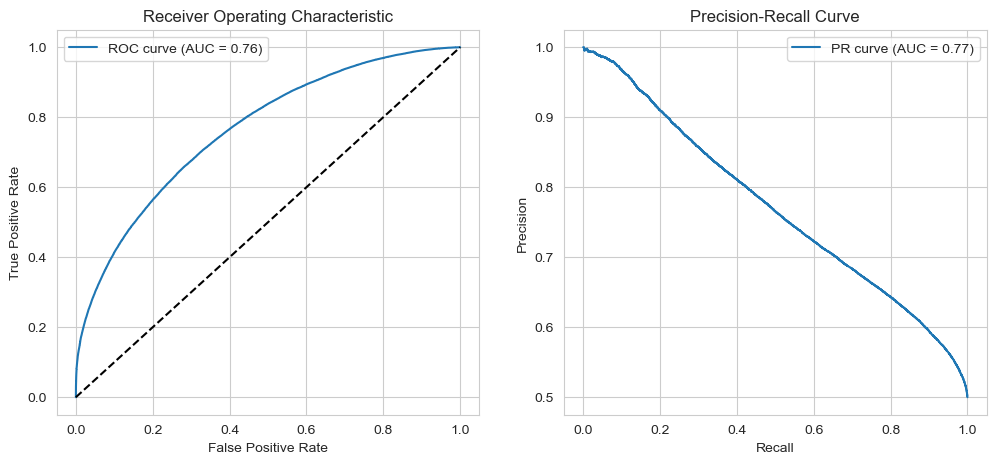

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# plot ROC and PR curves
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)
pr_auc = auc(recall, precision)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

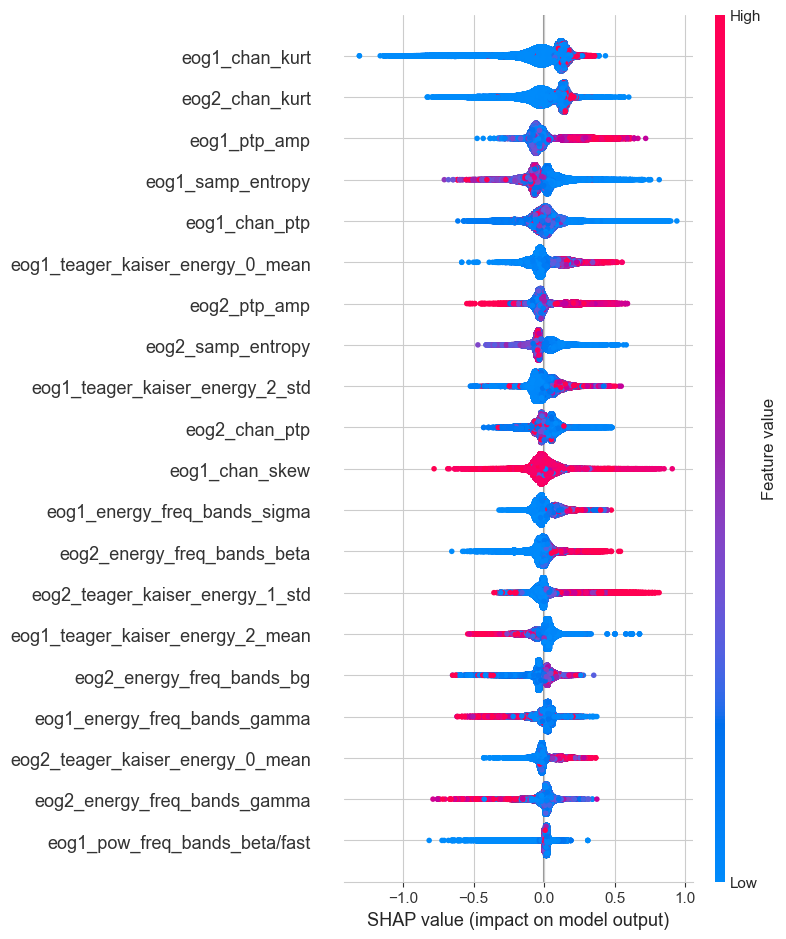

In [29]:
# shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_feat)
shap.summary_plot(shap_values, x_feat, max_display=20)

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.


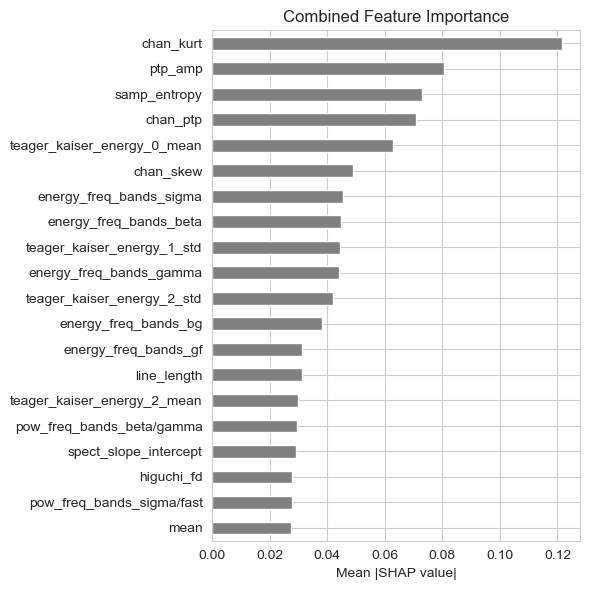

In [31]:
import pandas as pd
import numpy as np
import shap

# Step 1: Get feature names without prefix
simplified_names = x_feat.columns.str.replace(r'^(eog1_|eog2_)', '', regex=True)

# Step 2: Create a DataFrame of SHAP values and assign simplified names
shap_df = pd.DataFrame(np.abs(shap_values), columns=simplified_names)

# Step 3: Group by simplified name and sum or mean
# You can use .mean() or .sum() depending on how you want to rank
shap_mean = shap_df.groupby(shap_df.columns, axis=1).mean().mean(axis=0)

# Step 4: Plot top N features
top_features = shap_mean.sort_values(ascending=False).head(20)

# Optional: horizontal bar plot
top_features.plot(kind='barh', figsize=(6, 6), color='gray')
plt.xlabel('Mean |SHAP value|')
plt.title('Combined Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# נניח שיש לך:
# y = np.array([...])
# x_feat = pd.DataFrame(...)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_list, sens_list, spec_list, prec_list, rec_list, f1_list = [], [], [], [], [], []

for train_idx, test_idx in kf.split(x_feat, y):
    X_train, X_test = x_feat.iloc[train_idx], x_feat.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # מודל לדוגמה (אפשר להחליף בכל מודל)
    model = xgb.XGBClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # חישוב מטריקות
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)  # recall = sensitivity
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Sensitivity = recall, Specificity = TN / (TN + FP)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    acc_list.append(acc)
    sens_list.append(rec)
    spec_list.append(spec)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

# ממוצעים
acc_mean = np.mean(acc_list)
sens_mean = np.mean(sens_list)
spec_mean = np.mean(spec_list)
prec_mean = np.mean(prec_list)
rec_mean = np.mean(rec_list)
f1_mean = np.mean(f1_list)




In [30]:
# הדפסה בפורמט המבוקש
print(
    f"The original model achieved an accuracy of {acc_mean:.4f}, "
    f"sensitivity of {sens_mean:.4f}, specificity of {spec_mean:.4f}, "
    f"precision of {prec_mean:.4f}, recall of {rec_mean:.4f}, "
    f"and F1 score of {f1_mean:.4f}."
)

The original model achieved an accuracy of 0.6906, sensitivity of 0.6795, specificity of 0.7017, precision of 0.6949, recall of 0.6795, and F1 score of 0.6871.


In [31]:
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.7671233473548407

In [32]:
average_precision_score(y_test, model.predict_proba(X_test)[:, 1])

0.7726954775378994

In [30]:
print('done')

done


In [8]:
    
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(x_feat, y):
    print(f'Fold {i}')
    i += 1
    model = xgb.XGBClassifier()
    #model = LGBMClassifier()
    x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    model.fit(x_train_fold, y_train_fold)
    y_pred = model.predict(x_test_fold)
    # y_pred = model.predict_proba(x_test_fold).T
    # y_pred = [p > 0.8 for p in y_pred[1]]
    y_true = y_test_fold
    # save scores in dict
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))
    # metrics['FP/min'].append(fp / (len(test_index) / 4))

# print results as df
results = pd.DataFrame(metrics)
# add mean row
results.loc['mean'] = results.mean()
print(sum(y)/len(y))
results

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
0.5


,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.763744,0.759186,0.772528,0.754960,0.765799,0.763744,0.700228
1,0.762391,0.758348,0.770224,0.754558,0.764240,0.762391,0.698987
2,0.764929,0.760073,0.774266,0.755592,0.767104,0.764929,0.701365
3,0.761630,0.757390,0.769867,0.753393,0.763577,0.761630,0.698156
4,0.762488,0.757765,0.771649,0.753327,0.764644,0.762488,0.698904
mean,0.763036,0.758552,0.771707,0.754366,0.765073,0.763036,0.699528


In [10]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Initialize containers
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}
all_y_true = []
all_y_prob = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(x_feat, y):
    print(f'Fold {i}')
    i += 1
    model = xgb.XGBClassifier()  # avoid warning
    x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(x_train_fold, y_train_fold)
    y_prob = model.predict_proba(x_test_fold)[:, 1]  # probabilities for class 1
    y_pred = (y_prob > 0.5).astype(int)  # thresholding at 0.5
    
    y_true = y_test_fold
    all_y_true.extend(y_true)
    all_y_prob.extend(y_prob)

    # save metrics
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_prob))
    metrics['PRAUC'].append(average_precision_score(y_true, y_prob))

# Create results table
results = pd.DataFrame(metrics)
results.loc['mean'] = results.mean()
print("Positive class ratio:", sum(y)/len(y))
results

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Positive class ratio: 0.5


,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.691008,0.693682,0.684105,0.697911,0.688860,0.765648,0.772923
1,0.693594,0.697521,0.683653,0.703534,0.690517,0.769405,0.775377
2,0.691862,0.697729,0.677026,0.706697,0.687221,0.765583,0.771551
3,0.693092,0.697901,0.680942,0.705241,0.689317,0.767562,0.776140
4,0.687494,0.692928,0.673411,0.701576,0.683030,0.761794,0.767891
mean,0.691410,0.695952,0.679827,0.702992,0.687789,0.765999,0.772776


In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
# Compute ROC and PR curves from all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(all_y_true, all_y_prob)

# שמירה של ROC ו־PR ל-CSV
# pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv('figures/roc_curve_ub_asym.csv', index=False)
pd.DataFrame({'recall': recall, 'precision': precision}).to_csv('figures/pr_curve_b3000_sym.csv', index=False)

# שמירה של ערכי AUC ל-CSV
metrics_df = pd.DataFrame({
    'metric': ['ROC AUC', 'PR AUC'],
    'value': [roc_auc, pr_auc]
})
# metrics_df.to_csv('figures/roc_curve_ub_asym_metrics.csv', index=False)


In [12]:
[roc_auc, pr_auc]

[0.7660036044357829, 0.7727612032483431]

In [32]:
import joblib

# שמירת תוצאות לניתוח מאוחר
results_df = pd.DataFrame({
    'y_true': all_y_true,
    'y_prob': all_y_prob,
    'y_pred': [int(p > 0.5) for p in all_y_prob]
})
results_df.to_csv('figures/confusion_bmax_asym_metrics.csv', index=False)


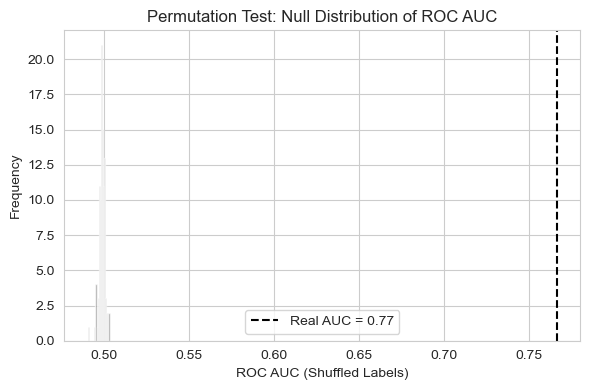

In [53]:
#TODO: run during the night
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

n_shuffles = 100
shuffled_scores = []

for i in range(n_shuffles):
    y_shuffled = shuffle(y, random_state=i)
    
    score = cross_val_score(
        xgb.XGBClassifier(), x_feat, y_shuffled,
        cv=5, scoring='roc_auc'
    ).mean()
    
    shuffled_scores.append(score)

# Real model score (from your actual model earlier)
real_score = results['ROCAUC'].mean()


In [56]:
# save suffled scores
joblib.dump(shuffled_scores, f'../validation_models_v3/shuffled_scores_xgb_b3000_210f.pkl')

['../validation_models_v3/shuffled_scores_xgb_b3000_210f.pkl']

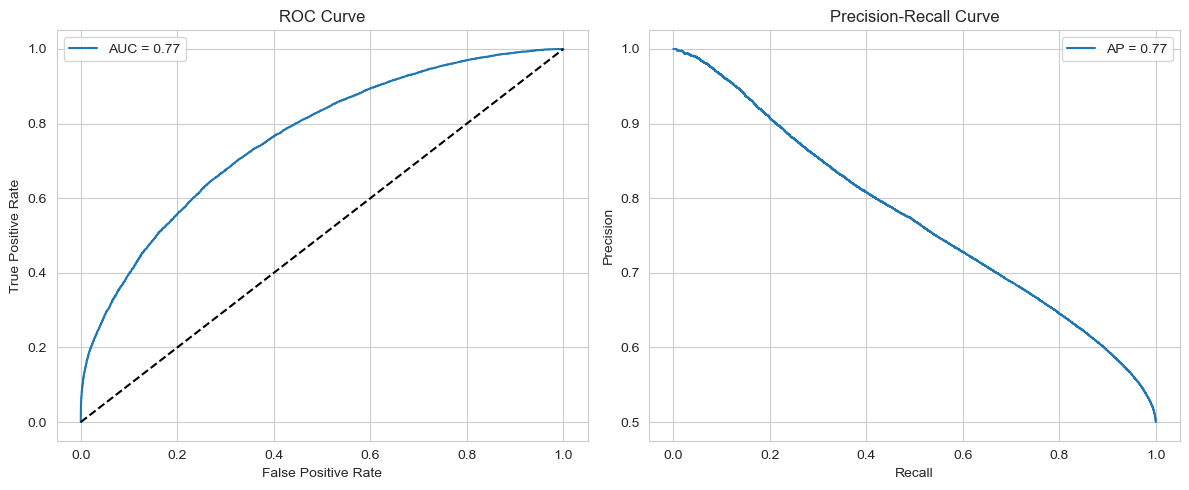

In [29]:

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(all_y_true, all_y_prob):.2f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR Curve
axes[1].plot(recall, precision, label=f'AP = {average_precision_score(all_y_true, all_y_prob):.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# take also the cell before and after as right for 1 prediction 
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, average_precision_score,
                           confusion_matrix)

def adjust_predictions_with_tolerance(y_true, y_pred):
    """
    Adjust predictions so that predicted 1s are considered correct if:
    - The actual label is 1, OR
    - The adjacent positions (before or after) have label 1
    
    Returns adjusted y_true and y_pred for metric calculation
    """
    # Convert to numpy arrays to handle indexing properly
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)
    
    y_true_adj = y_true_array.copy()
    y_pred_adj = y_pred_array.copy()
    
    # For each predicted 1, check if it should be considered correct
    for i in range(len(y_pred_array)):
        if y_pred_array[i] == 1:  # Only check predicted positives
            # Check if current position or adjacent positions have true label 1
            adjacent_true = False
            
            # Check current position
            if y_true_array[i] == 1:
                adjacent_true = True
            
            # Check previous position (if exists)
            if i > 0 and y_true_array[i-1] == 1:
                adjacent_true = True
                
            # Check next position (if exists)
            if i < len(y_true_array) - 1 and y_true_array[i+1] == 1:
                adjacent_true = True
            
            # If adjacent positions have 1, adjust the true label for this position
            if adjacent_true:
                y_true_adj[i] = 1
    
    return y_true_adj, y_pred_adj

# Your main cross-validation loop with modifications
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1

for train_index, test_index in kf.split(x_feat, y):
    print(f'Fold {i}')
    i += 1
    model = xgb.XGBClassifier()
    #model = LGBMClassifier()
    x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    model.fit(x_train_fold, y_train_fold)
    y_pred = model.predict(x_test_fold)
    
    # Apply tolerance adjustment
    y_true_adj, y_pred_adj = adjust_predictions_with_tolerance(y_test_fold, y_pred)
    
    # Calculate metrics with adjusted labels
    metrics['accuracy'].append(accuracy_score(y_true_adj, y_pred_adj))
    metrics['precision'].append(precision_score(y_true_adj, y_pred_adj))
    metrics['sensitivity'].append(recall_score(y_true_adj, y_pred_adj))
    metrics['f1'].append(f1_score(y_true_adj, y_pred_adj))
    
    tn, fp, fn, tp = confusion_matrix(y_true_adj, y_pred_adj).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    
    # For ROC AUC and PR AUC, we need probability scores
    # You might want to use the original y_true for these metrics
    # or use adjusted labels - depends on your specific needs
    y_pred_proba = model.predict_proba(x_test_fold)[:, 1]  # Get probabilities for class 1
    metrics['ROCAUC'].append(roc_auc_score(y_true_adj, y_pred_proba))
    metrics['PRAUC'].append(average_precision_score(y_true_adj, y_pred_proba))

# Print results as df
results = pd.DataFrame(metrics)
# Add mean row
results.loc['mean'] = results.mean()
print(sum(y)/len(y))
results

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
0.5


,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.691033,0.693733,0.684121,0.697946,0.688893,0.765689,0.772998
1,0.693594,0.697521,0.683653,0.703534,0.690517,0.769405,0.775377
2,0.691887,0.697780,0.677042,0.706733,0.687255,0.765616,0.771601
3,0.693117,0.697952,0.680958,0.705277,0.689350,0.767592,0.776183
4,0.687494,0.692928,0.673411,0.701576,0.683030,0.761794,0.767891
mean,0.691425,0.695983,0.679837,0.703013,0.687809,0.766019,0.772810


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


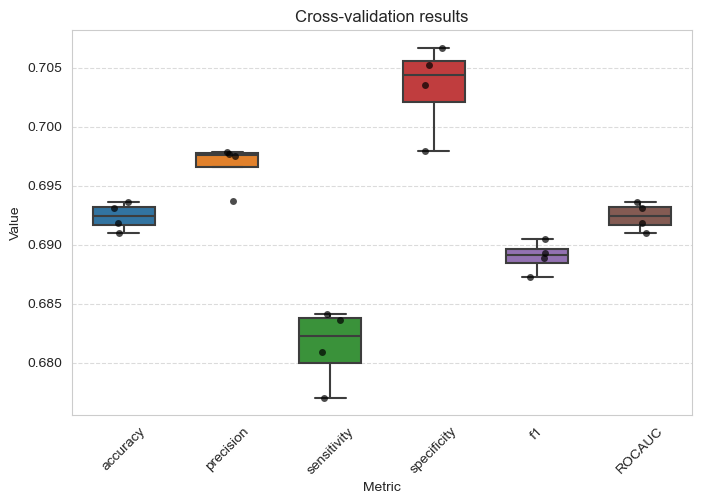

In [56]:
# Remove the mean row
results = results.iloc[:-1]

# Convert to long format
results_long = results.melt(var_name="Metric", value_name="Value", ignore_index=False)
results_long["Fold"] = results_long.index + 1  # Assign fold numbers

# Exclude PRAUC
results_long = results_long[results_long["Metric"] != "PRAUC"]

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Metric", y="Value", data=results_long, width=0.6, showfliers=False)
sns.stripplot(x="Metric", y="Value", data=results_long, jitter=True, dodge=True, color='black', alpha=0.7)

# Formatting
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title("Cross-validation results")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


In [57]:
# proba
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(x_feat, y):
    print(f'Fold {i}')
    i += 1
    model = xgb.XGBClassifier()
    #model = LGBMClassifier()
    x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    model.fit(x_train_fold, y_train_fold)
    y_pred = model.predict_proba(x_test_fold).T
    y_pred = [p > 0.8 for p in y_pred[1]]
    y_true = y_test_fold
    # save scores in dict
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))
    # metrics['FP/min'].append(fp / (len(test_index) / 4))

# print results as df
results = pd.DataFrame(metrics)
# add mean row
results.loc['mean'] = results.mean()
results

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.578873,0.926439,0.171353,0.986394,0.289213,0.578873,0.573071
1,0.575886,0.928066,0.164525,0.987248,0.279500,0.575886,0.570427
2,0.577719,0.921110,0.169997,0.985440,0.287022,0.577719,0.571587
3,0.575309,0.935540,0.161763,0.988854,0.275833,0.575309,0.570454
4,0.576966,0.926782,0.167135,0.986796,0.283199,0.576966,0.571330
mean,0.576950,0.927587,0.166955,0.986946,0.282953,0.576950,0.571374


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


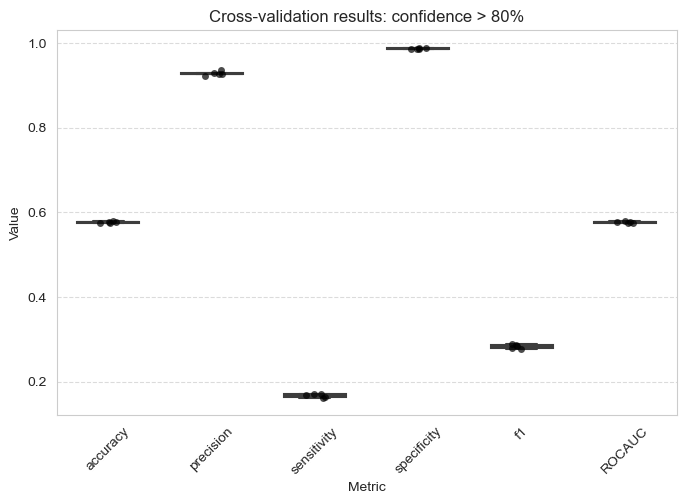

In [58]:
# Remove the mean row
results = results.iloc[:-1]

# Convert to long format
results_long = results.melt(var_name="Metric", value_name="Value", ignore_index=False)
results_long["Fold"] = results_long.index + 1  # Assign fold numbers

# Exclude PRAUC
results_long = results_long[results_long["Metric"] != "PRAUC"]

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Metric", y="Value", data=results_long, width=0.6, showfliers=False)
sns.stripplot(x="Metric", y="Value", data=results_long, jitter=True, dodge=True, color='black', alpha=0.7)

# Formatting
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title("Cross-validation results: confidence > 80%")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [11]:
# leave one subject out
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
# if col exist rename it
if 'eog1_subj' in x.columns:
    x.rename(columns={'eog1_subj': 'subj'}, inplace=True)
for subj in [x for x in clean_subjects if x not in less_10]:
    print(f'Processing {subj}')
    x_train = x_feat[x['subj'] != subj]
    y_train = y[x['subj'] != subj]
    x_test = x_feat[x['subj'] == subj]
    y_test = y[x['subj'] == subj]
    #model = LGBMClassifier()
    model = xgb.XGBClassifier()
    model.fit(x_train, y_train)
    #y_pred = model.predict_proba(x_test_fold).T
    #y_pred = [p > 0.8 for p in y_pred[1]]
    y_pred = model.predict(x_test)
    y_true = y_test
    # save scores in dict
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))
    # metrics['FP/min'].append(fp / (len(test_index) / 4))
    
# print results as df
results = pd.DataFrame(metrics, index=[x for x in clean_subjects if x not in less_10])
# add mean row
results.loc['mean'] = results.mean()
results

Processing 013
Processing 017
Processing 018
Processing 38
Processing 39
Processing 44
Processing 47


KeyboardInterrupt: 

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


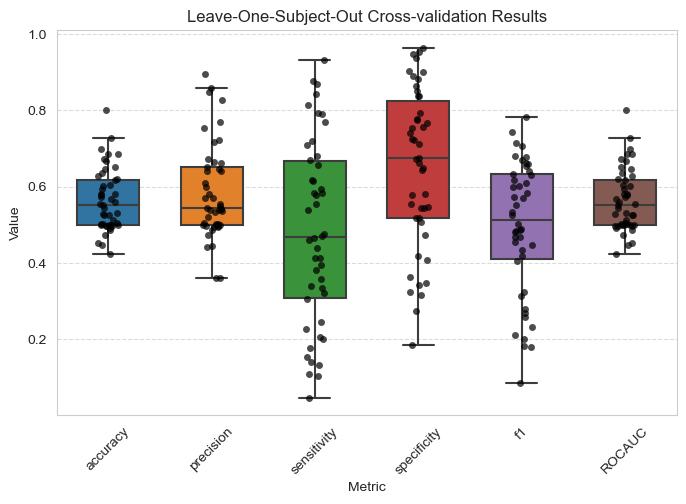

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Remove the mean row
results = results.iloc[:-1]

# Convert results to long format
results_long = results.melt(var_name="Metric", value_name="Value", ignore_index=False)
results_long["Subject"] = results_long.index  # Assign subjects

# Exclude PRAUC if needed
results_long = results_long[results_long["Metric"] != "PRAUC"]

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Metric", y="Value", data=results_long, width=0.6, showfliers=False)
sns.stripplot(x="Metric", y="Value", data=results_long, jitter=True, dodge=True, color='black', alpha=0.7)

# Formatting
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title("Leave-One-Subject-Out Cross-validation Results")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# use shap to explain model predictions
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_fold)
shap.summary_plot(shap_values, x_test_fold)

In [19]:
# print feature importance with colmn name
# feature_importance = pd.DataFrame(model.feature_importances_, index=x_feat.columns, columns=['importance'])
feature_importance = pd.DataFrame(model.feature_importances_, index=x_feat.columns, columns=['importance'])
feature_importance.sort_values(by='importance', ascending=False)
# feature_importance.to_csv('feature_importance_1.csv')

,importance
eog1_ptp_amp,0.050579
eog2_ptp_amp,0.043560
eog1_teager_kaiser_energy_0_mean,0.023311
eog2_energy_freq_bands_bg,0.021143
eog2_chan_kurt,0.018089
...,...
eog2_pow_freq_bands_fast/beta,0.000000
eog1_pow_freq_bands_alpha/theta,0.000000
eog2_pow_freq_bands_gamma/theta,0.000000
eog2_pow_freq_bands_gamma/sigma,0.000000


In [ ]:
# permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(model, x_test_fold, y_test_fold, n_repeats=10, random_state=8, n_jobs=2)
perm_sorted_idx = result.importances_mean.argsort()
tree_importance_sorted_idx = np.argsort(model.feature_importances_)
tree_indices = np.arange(0, len(model.feature_importances_)) + 0.5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 15))
ax1.barh(tree_indices, model.feature_importances_[tree_importance_sorted_idx], height=0.7)
ax1.set_yticklabels(x_test_fold.columns[tree_importance_sorted_idx])
ax1.set_yticks(tree_indices)
ax1.set_ylim((0, len(model.feature_importances_)))
ax2.boxplot(result.importances[perm_sorted_idx].T, vert=False, labels=x_test_fold.columns[perm_sorted_idx])
fig.tight_layout()
plt.show()

In [22]:
# Extract the mean and standard deviation of the permutation importances
perm_importance_mean = result.importances_mean
perm_importance_std = result.importances_std
feature_names = x_test_fold.columns

# Create a DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance_mean,
    'Importance_Std': perm_importance_std
})

# Sort by importance mean
perm_importance_df = perm_importance_df.sort_values(by='Importance_Mean', ascending=False)

# Save to CSV
perm_importance_df.to_csv('permutation_importance_results.csv', index=False)

In [355]:
plt.figure(figsize=(8,8))
pai = x[y==1]['subj'].value_counts()
plt.pie(x=pai, labels=pai.index, startangle=30, autopct='%1.2f%%', pctdistance=0.80, explode=[0.05] * len(pai))
### Add a hole in the pie  
hole = plt.Circle((0, 0), 0.65, facecolor='white')
plt.gcf().gca().add_artist(hole)

KeyError: 'subj'

<Figure size 800x800 with 0 Axes>

In [23]:
subj = '38'
# model = joblib.load(r'C:\repos\spikes_notebooks\validation_models_v3\lgbm_s50_f36_b_6000max.pkl')
# get models feature names
x.rename(columns={'eog1_subj': 'subj'}, inplace=True)
x_train = x_feat[x['subj'] != subj]
y_train = y[x['subj'] != subj]
x_test = x_feat[x['subj'] == subj]
y_test = y[x['subj'] == subj]
model = xgb.XGBClassifier()
model.fit(x_train, y_train)
y_depth = subj_data[subj]['y']
model_feat = model.get_booster().feature_names
subj_feat = pd.concat([subj_data[subj]['eog1'], subj_data[subj]['eog2']], axis=1, ignore_index=True) 
subj_feat.columns = [f'eog1_{col}' for col in subj_data[subj]['eog1'].columns] + [f'eog2_{col}' for col in subj_data[subj]['eog2'].columns]
subj_selected_feat = subj_feat[model_feat]
y_proba = model.predict_proba(subj_selected_feat).T
y_scalp = [p > 0.8 for p in y_proba[1]]
index_map = map_nan_index('D:\\clean_zeeg\\P%s_mtl_clean.fif' % subj)
#some problem with empty y_scalp
scalp_indexes = np.where(np.array(y_scalp) == True)[0]
scalp_onsets = [index_map[int(x)] / 4 for x in scalp_indexes]
depth_indexes = np.where(y_depth == 1)[0]
depth_onsets = [index_map[int(x)] / 4 for x in depth_indexes]
both = [x for x in scalp_onsets if x in depth_onsets]
depth_without_both = [x for x in depth_onsets if x not in both]
scalp_without_both = [x for x in scalp_onsets if x not in both]
raw = mne.io.read_raw('D:\\clean_zeeg\\P%s_mtl_clean.fif' % subj)
print(sum(y_scalp), sum(y_depth), len(both))
# all annot
annot = mne.Annotations(scalp_without_both, [0.25] * len(scalp_without_both), ['scalp'] * len(scalp_without_both)).append(depth_without_both, [0.25] * len(depth_without_both), ['depth'] * len(depth_without_both)).append(both, [0.25] * len(both), ['both'] * len(both))
# only depth and both
# annot = mne.Annotations(depth_onsets, [0.25] * len(depth_onsets), ['depth'] * len(depth_onsets)).append(both, [0.25] * len(both), ['both'] * len(both))
# only both
# annot = mne.Annotations(both, [0.25] * len(both), ['both'] * len(both))
raw.set_annotations(annot)
# mne.set_bipolar_reference(raw, raw.ch_names[0], raw.ch_names[1], ch_name='bi', drop_refs=False).plot(
#     duration=30, scalings='auto')

raw.crop(tmin=0, tmax=60*60*3).plot(duration=30, scalings='auto')

Opening raw data file D:\clean_zeeg\P38_mtl_clean.fif...


This filename (D:\clean_zeeg\P38_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz


Isotrak not found
    Range : 0 ... 19870999 =      0.000 ... 19870.999 secs
Ready.
Opening raw data file D:\clean_zeeg\P38_mtl_clean-1.fif...
Isotrak not found
    Range : 19871000 ... 37044999 =  19871.000 ... 37044.999 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Setting 1787181 of 37045000 (4.82%) samples to NaN, retaining 35257819 (95.18%) samples.
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
n

This filename (D:\clean_zeeg\P38_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz


Isotrak not found
    Range : 19871000 ... 37044999 =  19871.000 ... 37044.999 secs
Ready.
10359 1058 192


In [18]:
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
import xgboost as xgb
from collections import OrderedDict
import time, sys, re

# ----------------------------
# הגדרות
# ----------------------------
SUBJECTS = [s for s in all_subjects if s not in less_10]
RANDOM_STATE = 8
POS_THRESHOLD = 0.80
SAVE_PATH = "loso_subject_metrics.csv"

# עמודות מטא־דאטה שכדאי להסיר אם קיימות בשם
META_PATTERNS = re.compile(r'(?:^|_)(' + '|'.join([
    'subj','subject','chan','channel','chan_name','epoch','epoch_id'
]) + r')(?:_|$)', flags=re.IGNORECASE)

def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    """שומר רק עמודות נומריות, ומסיר במפורש עמודות מטא־דאטה אם חמקו.
    מחזיר DataFrame נומרי בלבד."""
    # זריקת עמודות שמזוהות כמטא־דאטה לפי שם
    to_drop_by_name = [c for c in df.columns if META_PATTERNS.search(str(c))]
    if to_drop_by_name:
        df = df.drop(columns=to_drop_by_name, errors='ignore')
    # שמירה רק על עמודות נומריות/בוליאניות
    num_df = df.select_dtypes(include=['number', 'bool']).copy()
    # המרה לבוליאן->אינט אם יש
    for c in num_df.select_dtypes(include=['bool']).columns:
        num_df[c] = num_df[c].astype('int8')
    return num_df

def build_subject_features(subj):
    """מחזיר X (DataFrame) ו-y (numpy array) לנבדק יחיד, לאחר חיבור EOG וניקוי."""
    eog1 = subj_data[subj]['eog1'].reset_index(drop=True)
    eog2 = subj_data[subj]['eog2'].reset_index(drop=True)
    y = np.asarray(subj_data[subj]['y'])
    X = pd.concat([eog1, eog2], axis=1, ignore_index=True)
    # לתת שמות – אם המקור כבר כולל subj/chan וכו', זה יזוהה ב-clean_features וייפלט
    X.columns = [f"eog1_{c}" for c in eog1.columns] + [f"eog2_{c}" for c in eog2.columns]
    X = clean_features(X)
    return X, y

rows = []
start_all = time.time()
print(f"Starting LOSO over {len(SUBJECTS)} subjects | threshold={POS_THRESHOLD}")

for idx, test_subj in enumerate(SUBJECTS, start=1):
    t0 = time.time()
    print(f"\n[{idx}/{len(SUBJECTS)}] Processing subject: {test_subj}")
    sys.stdout.flush()

    # מבחן (לא מאוזן) – כבר נקי מנון־נומרי
    X_test_full, y_test = build_subject_features(test_subj)

    # אימון (מאוזן per-subject)
    X_train_list, y_train_list = [], []
    rus = RandomUnderSampler(random_state=RANDOM_STATE)

    for train_subj in SUBJECTS:
        if train_subj == test_subj:
            continue
        X_s, y_s = build_subject_features(train_subj)   # כבר נומרי בלבד
        X_bal, y_bal = rus.fit_resample(X_s, y_s)
        X_train_list.append(X_bal)
        y_train_list.append(y_bal)

    X_train = pd.concat(X_train_list, axis=0, ignore_index=True)
    y_train = np.concatenate(y_train_list, axis=0)

    # מוודאים התאמת עמודות בין train ל-test
    common_cols = X_train.columns
    X_test = X_test_full.reindex(columns=common_cols, fill_value=0)

    # אימון
    model = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        eval_metric="logloss",
        # לא משתמשים ב-enable_categorical כי הסרנו object
    )
    model.fit(X_train, y_train)

    # חיזוי
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= POS_THRESHOLD).astype(int)

    # מטריקות
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        rocauc = roc_auc_score(y_test, y_proba)
    except ValueError:
        rocauc = np.nan
    try:
        prauc = average_precision_score(y_test, y_proba)
    except ValueError:
        prauc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    predicted_events = int(y_pred.sum())
    true_events = int(y_test.sum())
    total_samples = int(len(y_test))

    # הדפסה למסך
    elapsed = time.time() - t0
    print(
        f"  samples={total_samples} | true_events={true_events} | predicted_events={predicted_events}\n"
        f"  TP={tp} FP={fp} TN={tn} FN={fn}\n"
        f"  Acc={acc:.3f} | Prec={prec:.3f} | Sens={rec:.3f} | Spec={specificity:.3f} | "
        f"F1={f1:.3f} | ROC-AUC={rocauc:.3f} | PR-AUC={prauc:.3f}\n"
        f"  Done in {elapsed:.1f}s"
    )
    sys.stdout.flush()

    rows.append(OrderedDict(
        subject_id=test_subj,
        total_samples=total_samples,
        true_events=true_events,
        predicted_events=predicted_events,
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        accuracy=acc,
        precision=prec,
        sensitivity=rec,
        specificity=specificity,
        f1=f1,
        roc_auc=rocauc,
        pr_auc=prauc,
        threshold=POS_THRESHOLD
    ))

# טבלת תוצאות + ממוצע/סטיית תקן
results_df = pd.DataFrame(rows)
metric_cols = [
    'total_samples','true_events','predicted_events','tp','fp','tn','fn',
    'accuracy','precision','sensitivity','specificity','f1','roc_auc','pr_auc'
]
mean_row = results_df[metric_cols].mean(numeric_only=True)
std_row  = results_df[metric_cols].std(ddof=1, numeric_only=True)
mean_row['subject_id'] = 'MEAN'
mean_row['threshold']  = POS_THRESHOLD
std_row['subject_id']  = 'STD'
std_row['threshold']   = POS_THRESHOLD

cols_order = ['subject_id','total_samples','true_events','predicted_events',
              'tp','fp','tn','fn',
              'accuracy','precision','sensitivity','specificity','f1','roc_auc','pr_auc',
              'threshold']

final_df = pd.concat([results_df, pd.DataFrame([mean_row]), pd.DataFrame([std_row])], ignore_index=True)
final_df = final_df[cols_order]

final_df.to_csv(SAVE_PATH, index=False)
print(f"\nAll done in {time.time()-start_all:.1f}s. Saved results to: {SAVE_PATH}")

Starting LOSO over 46 subjects | threshold=0.8

[1/46] Processing subject: 013
  samples=108852 | true_events=860 | predicted_events=11918
  TP=224 FP=11694 TN=96298 FN=636
  Acc=0.887 | Prec=0.019 | Sens=0.260 | Spec=0.892 | F1=0.035 | ROC-AUC=0.684 | PR-AUC=0.018
  Done in 167.2s

[2/46] Processing subject: 017
  samples=138079 | true_events=1064 | predicted_events=1660
  TP=77 FP=1583 TN=135432 FN=987
  Acc=0.981 | Prec=0.046 | Sens=0.072 | Spec=0.988 | F1=0.057 | ROC-AUC=0.766 | PR-AUC=0.027
  Done in 171.2s

[3/46] Processing subject: 018
  samples=15395 | true_events=62 | predicted_events=130
  TP=0 FP=130 TN=15203 FN=62
  Acc=0.988 | Prec=0.000 | Sens=0.000 | Spec=0.992 | F1=0.000 | ROC-AUC=0.495 | PR-AUC=0.004
  Done in 164.0s

[4/46] Processing subject: 38
  samples=140986 | true_events=1058 | predicted_events=2500
  TP=61 FP=2439 TN=137489 FN=997
  Acc=0.976 | Prec=0.024 | Sens=0.058 | Spec=0.983 | F1=0.034 | ROC-AUC=0.635 | PR-AUC=0.015
  Done in 161.6s

[5/46] Processing su

In [219]:
all_results = pd.DataFrame()

# combine all subjects
for subj in [x for x in all_subjects if x not in less_10]:
    x = pd.DataFrame()
    y = np.array([])
    print(f'Processing {subj}')
    eog1_subj = subj_data[subj]['eog1']
    eog2_subj = subj_data[subj]['eog2']
    y_subj = subj_data[subj]['y']
    eog1_subj.reset_index(drop=True, inplace=True)
    eog2_subj.reset_index(drop=True, inplace=True)
    x_subj = pd.concat([eog1_subj, eog2_subj], axis=1, ignore_index=True)
    x_subj.columns = [f'eog1_{col}' for col in eog1_subj.columns] + [f'eog2_{col}' for col in eog2_subj.columns]
    # undersample
    rus = RandomUnderSampler(random_state=8)
    x, y = rus.fit_resample(x_subj, y_subj)
    meta_data = ['subj', 'epoch_id', 'chan_name', 'epoch']
    x_feat = x[x.columns[~x.columns.str.contains('|'.join(meta_data))]]
    # save model results
    metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
    for train_index, test_index in kf.split(x_feat, y):
        model = xgb.XGBClassifier()
        x_train_fold, x_test_fold = x_feat.iloc[train_index], x_feat.iloc[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]
        model.fit(x_train_fold, y_train_fold)
        y_pred = model.predict(x_test_fold)
        y_true = y_test_fold
        # save scores in dict
        metrics['accuracy'].append(accuracy_score(y_true, y_pred))
        metrics['precision'].append(precision_score(y_true, y_pred))
        metrics['sensitivity'].append(recall_score(y_true, y_pred))
        metrics['f1'].append(f1_score(y_true, y_pred))
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        metrics['specificity'].append(tn / (tn + fp))
        metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
        metrics['PRAUC'].append(average_precision_score(y_true, y_pred))
    
    # print results as df
    results = pd.DataFrame(metrics)
    results.loc['mean'] = results.mean()
    # Add subject ID and prepare for concatenation
    mean_row = results.loc['mean'].to_dict()  # Convert mean row to a dictionary
    mean_row['subject_id'] = subj  # Add the subject ID
    mean_row_df = pd.DataFrame([mean_row])  # Create a DataFrame from the dictionary
    
    # Concatenate to all_results
    all_results = pd.concat([all_results, mean_row_df], ignore_index=True)
    # Set the order of columns in all_results (optional)
    all_results = all_results[['subject_id'] + [col for col in all_results.columns if col != 'subject_id']]

Processing 013
[LightGBM] [Info] Number of positive: 688, number of negative: 688
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51116
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 688, number of negative: 688
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51117
[LightGBM] [Info] Number of data points in the train set: 1376, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 688, number of negative: 688
[LightGBM] [Info] Auto-choosing col-wise multi

In [220]:
all_results

,subject_id,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,013,0.693605,0.695805,0.690698,0.696512,0.692036,0.693605,0.634867
1,017,0.760337,0.750142,0.780069,0.740615,0.764548,0.760342,0.695514
2,018,0.574000,0.577807,0.580769,0.561538,0.574734,0.571154,0.562185
3,38,0.600659,0.604840,0.586006,0.615211,0.594807,0.600608,0.561970
4,39,0.511850,0.511736,0.498819,0.524821,0.504970,0.511820,0.506274
5,44,0.667115,0.657219,0.698472,0.635745,0.677073,0.667108,0.610298
6,47,0.572065,0.564881,0.615789,0.528421,0.586525,0.572105,0.548142
7,48,0.689706,0.689618,0.694118,0.685294,0.691262,0.689706,0.631486
8,51,0.830098,0.839842,0.817937,0.842324,0.828017,0.830131,0.777596
9,53,0.735810,0.728842,0.752958,0.718656,0.739853,0.735807,0.671929


In [221]:
# get mean of each col
all_results.iloc[:, 1:].mean()

accuracy       0.653196
precision      0.660980
sensitivity    0.644030
specificity    0.662250
f1             0.650931
ROCAUC         0.653140
PRAUC          0.612892
dtype: float64

In [ ]:
# raw data metrics
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
for subj in clean_subjects:
    print(f'Processing {subj}')
    x_train = x_feat[x['subj'] != subj]
    y_train = y[x['subj'] != subj]
    x_test = x_feat[x['subj'] == subj]
    y_test = y[x['subj'] == subj]
    model = LGBMClassifier()
    model.fit(x_train, y_train)
    y_depth = subj_data[subj]['y']
    model_feat = model.feature_name_
    subj_feat = pd.concat([subj_data[subj]['eog1'], subj_data[subj]['eog2']], axis=1, ignore_index=True) 
    subj_feat.columns = [f'eog1_{col}' for col in subj_data[subj]['eog1'].columns] + [f'eog2_{col}' for col in subj_data[subj]['eog2'].columns]
    subj_selected_feat = subj_feat[model_feat]
    y_proba = model.predict_proba(subj_selected_feat).T
    y_scalp = [p > 0.8 for p in y_proba[1]]
    index_map = map_nan_index('C:\\clean_zeeg\\P%s_mtl_clean.fif' % subj)
    #some problem with empty y_scalp
    scalp_indexes = np.where(np.array(y_scalp) == True)[0]
    scalp_onsets = [index_map[int(x)] / 4 for x in scalp_indexes]
    depth_indexes = np.where(y_depth == 1)[0]
    depth_onsets = [index_map[int(x)] / 4 for x in depth_indexes]
    both = [x for x in scalp_onsets if x in depth_onsets]
    depth_without_both = [x for x in depth_onsets if x not in both]
    scalp_without_both = [x for x in scalp_onsets if x not in both]
    print(sum(y_scalp), sum(y_depth), len(both))
    y_true = y_depth
    y_pred = y_scalp
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))

# print results as df
results = pd.DataFrame(metrics)
# add mean row
results.loc['mean'] = results.mean()
results

In [360]:
# print results as df
results = pd.DataFrame(metrics)
# add mean row
results.loc['mean'] = results.mean()
results

,accuracy,precision,sensitivity,specificity,f1,ROCAUC,PRAUC
0,0.958852,0.030610,0.137209,0.965396,0.050053,0.551302,0.011017
1,0.957249,0.041675,0.206767,0.963077,0.069368,0.584922,0.014729
2,0.796297,0.001944,0.096774,0.799126,0.003812,0.447950,0.003826
3,0.983107,0.000000,0.000000,0.983124,0.000000,0.491562,0.000017
4,0.984013,0.026149,0.031191,0.991217,0.028448,0.511204,0.008086
5,0.982263,0.007576,0.002257,0.995889,0.003478,0.499073,0.013699
6,0.991270,0.000000,0.000000,0.999578,0.000000,0.499789,0.008311
7,0.990959,0.000000,0.000000,0.991016,0.000000,0.495508,0.000058
8,0.999158,0.000000,0.000000,0.999914,0.000000,0.499957,0.000756
9,0.995902,0.142857,0.005882,0.999859,0.011299,0.502871,0.004797


In [3]:
# shaked data
shaked_x_raw = joblib.load(r"C:\repos\spikes_notebooks\paper\all_channels_common_subjects.pkl")
shaked_y_raw = np.load(r"C:\repos\spikes_notebooks\paper\common_subjects_y_true.npy")

In [5]:
# balance data
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=8)
shaked_x_b, shaked_y_b = rus.fit_resample(shaked_x_raw, shaked_y_raw)

In [6]:
shaked_x_b

,subj,C3_app_entropy,C3_decorr_time,C3_energy_freq_bands_theta,C3_energy_freq_bands_alpha,C3_energy_freq_bands_sigma,C3_energy_freq_bands_beta,C3_energy_freq_bands_gamma,C3_energy_freq_bands_fast,C3_higuchi_fd,...,EOG2_energy_freq_bands_bf,EOG2_energy_freq_bands_st,EOG2_energy_freq_bands_sg,EOG2_energy_freq_bands_sf,EOG2_energy_freq_bands_gt,EOG2_energy_freq_bands_gf,EOG2_energy_freq_bands_ft,EOG2_chan_ptp,EOG2_chan_skew,EOG2_chan_kurt
338451,44,0.205807,-1.000,0.262652,0.367720,0.210885,0.181103,0.205314,0.002631,1.053315,...,46.905406,0.313593,0.251718,9.960115,1.245811,39.568609,0.031485,158.180540,6.161725,872.872728
2296507,735,0.155222,0.031,0.335744,1.341267,1.725847,0.367750,0.159575,0.003804,1.025496,...,108.241941,2.962882,27.704346,322.420116,0.106946,11.637890,0.009190,85.718716,0.346772,32.944846
199234,39,0.195230,0.033,0.169083,0.047117,0.099338,0.273572,0.153976,0.001865,1.028184,...,53.508843,0.464844,0.104862,8.742242,4.432923,83.369192,0.053172,201.477094,-5.550085,1121.326249
46280,38,0.176205,0.029,0.896286,0.961525,0.382638,0.099164,0.084923,0.001838,1.020672,...,9.115737,2.626273,5.402666,14.526327,0.486107,2.688733,0.180794,52.467172,-0.102255,22.553883
656871,51,0.096320,0.040,0.126943,0.059820,0.007448,0.072285,0.082906,0.015992,1.083320,...,3.184482,0.019151,0.297153,0.517581,0.064450,1.741799,0.037002,66.096001,-1.206070,17.802545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699608,752,0.329881,0.037,0.142021,0.180588,0.288485,0.913687,0.626700,0.003823,1.058537,...,267.132241,0.273718,0.110733,34.763550,2.471867,313.939274,0.007874,41.986234,-0.715957,13.979186
2699609,752,0.201840,-1.000,0.851776,0.129027,0.209443,0.746444,0.996758,0.003022,1.066027,...,451.360705,0.842304,0.442149,103.511315,1.905024,234.109624,0.008137,41.986234,-0.715957,13.979186
2699646,752,0.176840,0.045,0.183445,0.146692,0.020414,0.459116,0.522151,0.000461,1.045458,...,2723.681384,2.481350,0.869649,2028.658343,2.853277,2332.731724,0.001223,41.986234,-0.715957,13.979186
2699658,752,0.418788,-1.000,0.021699,0.047326,0.207740,1.140088,1.462563,0.000968,1.078472,...,351.701906,1.180358,0.080612,142.931925,14.642374,1773.074555,0.008258,41.986234,-0.715957,13.979186


In [7]:
# balance data
shaked_x_b['pred'] = shaked_y_b
sampled_data_0 = pd.DataFrame()
sampled_data_1 = pd.DataFrame()
max_samples = 3000
for subj in shaked_x_b['subj'].unique():
    n_spikes = shaked_x_b[(shaked_x_b['subj'] == subj) & (shaked_x_b['pred'] == 1)].shape[0]
    print(subj, n_spikes)
    sample_count = min(max_samples, n_spikes)
    sampled_data_0 = pd.concat([sampled_data_0, shaked_x_b[(shaked_x_b['subj'] == subj) & (shaked_x_b['pred'] == 0)].sample(sample_count, replace=True, random_state=8)])
    sampled_data_1 = pd.concat([sampled_data_1, shaked_x_b[(shaked_x_b['subj'] == subj) & (shaked_x_b['pred'] == 1)].sample(sample_count, replace=True, random_state=8)])

sampled_data = pd.concat([sampled_data_1, sampled_data_0], ignore_index=True)
x_shaked = sampled_data.drop(columns='pred')
y_shaked = sampled_data['pred']
sampled_data

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


44 2765
735 30215
39 5172
38 4408
51 3575
723 13950
731 30745
713 28268
715 8438
752 6469
47 56
55 3235
54 7107
737 3907
53 1784
46 159
714 15115
744 3235
733 36820
734 7946
724 7984
746 12054
59 16
56 1169


,subj,C3_app_entropy,C3_decorr_time,C3_energy_freq_bands_theta,C3_energy_freq_bands_alpha,C3_energy_freq_bands_sigma,C3_energy_freq_bands_beta,C3_energy_freq_bands_gamma,C3_energy_freq_bands_fast,C3_higuchi_fd,...,EOG2_energy_freq_bands_st,EOG2_energy_freq_bands_sg,EOG2_energy_freq_bands_sf,EOG2_energy_freq_bands_gt,EOG2_energy_freq_bands_gf,EOG2_energy_freq_bands_ft,EOG2_chan_ptp,EOG2_chan_skew,EOG2_chan_kurt,pred
0,44,0.163820,0.040,0.088658,0.332043,2.109967,0.990454,0.105253,0.005847,1.026535,...,6.674313,18.991806,291.702261,0.351431,15.359375,0.022881,158.180540,6.161725,872.872728,1
1,44,0.021855,-1.000,0.025765,0.082046,0.073286,0.141085,0.132230,0.001568,1.029910,...,0.391882,1.325409,19.769136,0.295668,14.915501,0.019823,158.180540,6.161725,872.872728,1
2,44,0.204223,0.037,0.661515,0.627204,0.046958,0.399628,0.253641,0.001688,1.055385,...,0.039195,0.091581,4.834439,0.427979,52.788744,0.008107,158.180540,6.161725,872.872728,1
3,44,0.178241,0.039,0.135015,0.066326,0.017158,0.054062,0.017149,0.000953,1.021448,...,0.581559,0.699215,12.741567,0.831732,18.222676,0.045643,158.180540,6.161725,872.872728,1
4,44,0.253962,0.046,0.067171,0.055513,0.022541,0.137611,0.113528,0.000966,1.046672,...,0.850893,0.855853,21.642501,0.994204,25.287636,0.039316,158.180540,6.161725,872.872728,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119893,56,0.475583,0.011,0.028628,0.019491,0.018732,0.430940,0.306804,0.001226,1.081741,...,3.237649,0.147523,65.627633,21.946691,444.862719,0.049334,26.079818,0.337802,5.984814,0
119894,56,0.470860,0.010,0.015842,0.022899,0.020338,0.410139,0.781946,0.000725,1.096204,...,0.517990,0.052527,22.112443,9.861464,420.975062,0.023425,26.079818,0.337802,5.984814,0
119895,56,0.407131,0.014,0.062457,0.096495,0.121431,0.458467,0.845857,0.000968,1.069884,...,1.449127,0.176182,187.945009,8.225147,1066.763300,0.007710,26.079818,0.337802,5.984814,0
119896,56,0.472877,0.014,0.035846,0.023926,0.148394,0.211833,0.361251,0.001420,1.076209,...,2.837627,0.190513,87.291688,14.894691,458.193609,0.032507,26.079818,0.337802,5.984814,0


In [8]:
shaked_x_feat = x_shaked.dropna(axis=1).drop(columns='subj')

In [8]:
# train model on shaked data
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, average_precision_score,
                           confusion_matrix)
from xgboost import XGBClassifier
import pandas as pd
# Initialize metrics dictionary
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [],'f1': [], 'ROCAUC': [], 'PRAUC': []}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(shaked_x_feat, y_shaked):
    print(f'Fold {i}')
    i += 1
    model = XGBClassifier()
    x_train_fold, x_test_fold = shaked_x_feat.iloc[train_index], shaked_x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y_shaked[train_index], y_shaked[test_index]
    model.fit(x_train_fold, y_train_fold)
    y_pred = model.predict(x_test_fold)
    y_true = y_test_fold
    # save scores in dict
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))
    
# Print results as DataFrame
results = pd.DataFrame(metrics)
# Add mean row
results.loc['mean'] = results.mean()
print(results)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
      accuracy  precision  sensitivity  specificity        f1    ROCAUC  \
0     0.703503   0.699054     0.714679     0.692327  0.706780  0.703503   
1     0.704587   0.701627     0.711927     0.697248  0.706740  0.704587   
2     0.702544   0.697809     0.714512     0.690575  0.706062  0.702544   
3     0.700321   0.699303     0.702919     0.697723  0.701106  0.700321   
4     0.700571   0.700492     0.700726     0.700417  0.700609  0.700571   
mean  0.702305   0.699657     0.708952     0.695658  0.704259  0.702305   

         PRAUC  
0     0.642259  
1     0.643544  
2     0.641337  
3     0.640100  
4     0.640484  
mean  0.641545  


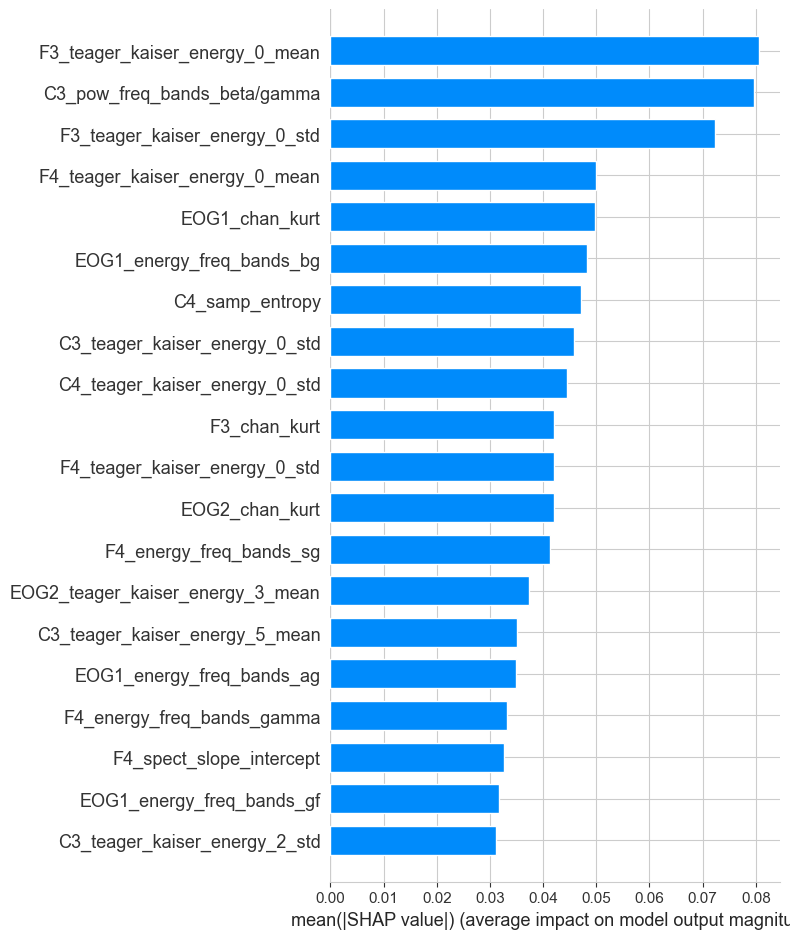

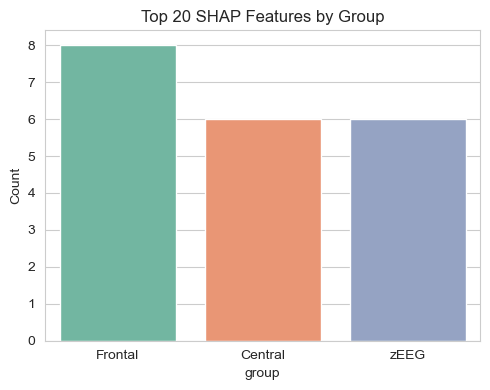

In [61]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = XGBClassifier()
model.fit(shaked_x_feat, y_shaked)
    
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shaked_x_feat)

# SHAP summary bar plot (top 20)
shap.summary_plot(shap_values, shaked_x_feat, plot_type="bar", max_display=20)

# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = shaked_x_feat.columns

# Create DataFrame and sort by importance
shap_importance_all = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap})
shap_importance = shap_importance_all.sort_values(by='mean_abs_shap', ascending=False).head(20)

# Map first letters to groups
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
shap_importance['group'] = shap_importance['feature'].str[0].map(group_labels)

# Count how many features in each group
group_counts = shap_importance['group'].value_counts().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Bar plot of group counts
plt.figure(figsize=(5, 4))
sns.barplot(x=group_counts.index, y=group_counts.values, palette='Set2')
plt.title('Top 20 SHAP Features by Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [62]:
shap_importance_all.to_csv('shap_importance_all.csv', index=False)

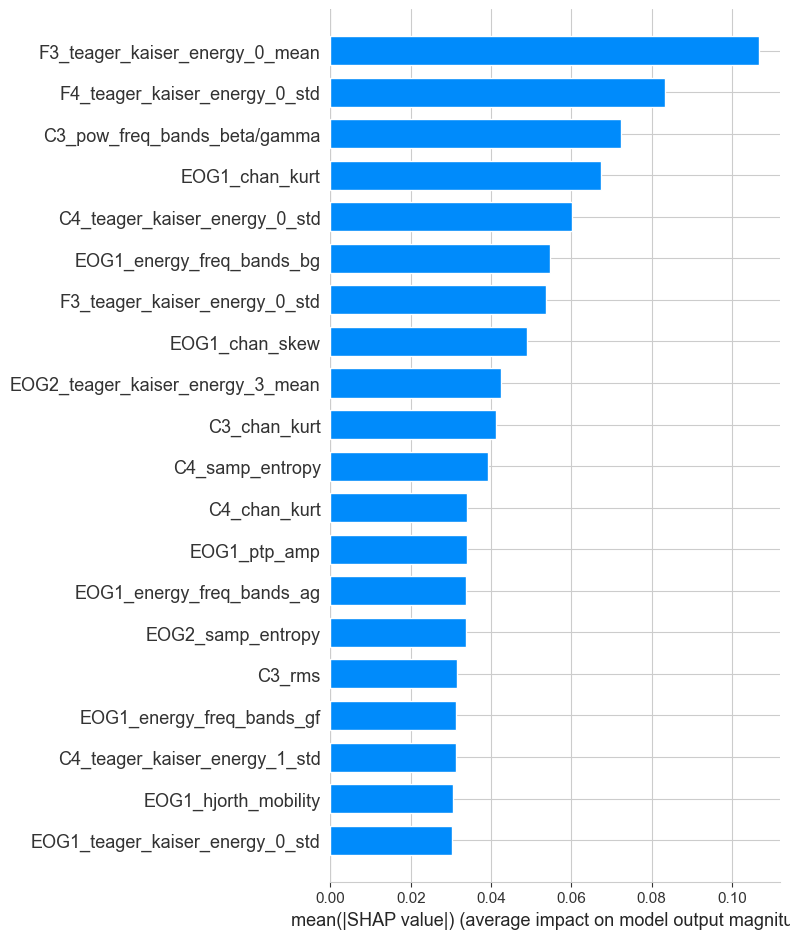

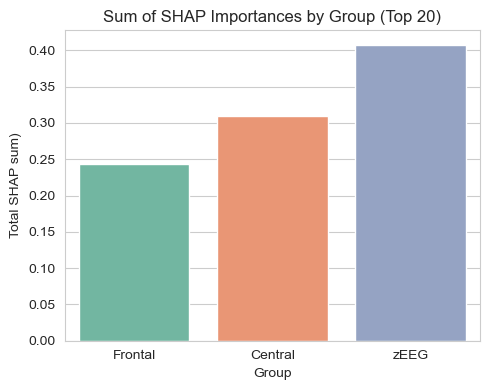

In [28]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_fold)

# SHAP summary bar plot (top 20)
shap.summary_plot(shap_values, x_test_fold, plot_type="bar", max_display=20)

# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = x_test_fold.columns

# Create DataFrame and sort by importance
shap_importance = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap})
shap_importance = shap_importance.sort_values(by='mean_abs_shap', ascending=False).head(20)

# Map first letters to group names
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
shap_importance['group'] = shap_importance['feature'].str[0].map(group_labels)

# Sum SHAP values per group
group_sums = shap_importance.groupby('group')['mean_abs_shap'].sum().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Bar plot of SHAP sums per group
plt.figure(figsize=(5, 4))
sns.barplot(x=group_sums.index, y=group_sums.values, palette='Set2')
plt.title('Sum of SHAP Importances by Group (Top 20)')
plt.xlabel('Group')
plt.ylabel('Total SHAP sum)')
plt.tight_layout()
plt.show()


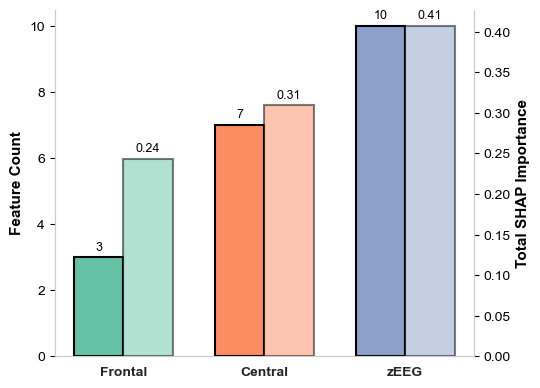

In [41]:
import pandas as pd
df_shap_summary = pd.read_csv('figures/feature_importence_summary.csv')

# Extract data
group_order = df_shap_summary['Group'].tolist()
ordered_counts = df_shap_summary['TopFeatureCount'].tolist()
ordered_sums = df_shap_summary['SHAPSum'].tolist()

# Correct unpacking of color palette with more colors than needed
colors = sns.color_palette('Set2', n_colors=3)
blue_fill, gray_fill, zeeeg_fill = colors

# Assign consistent colors
fill_colors = [blue_fill, gray_fill, zeeeg_fill]
edge_colors = ['black'] * 3

x = np.arange(len(group_order))
width = 0.35

fig, ax1 = plt.subplots(figsize=(5.5, 4))

# Left axis: feature count
bar1 = ax1.bar(x - width/2, ordered_counts, width,
               color=fill_colors, edgecolor=edge_colors, linewidth=1.5, zorder=3)
ax1.set_ylabel('Feature Count', fontsize=11, fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black', colors='black')
ax1.set_xticks(x)
ax1.set_xticklabels(group_order, fontsize=10, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.grid(False)

# Right axis: SHAP sum
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, ordered_sums, width,
               color=fill_colors, edgecolor=edge_colors, linewidth=1.5, zorder=2, alpha=0.5)
ax2.set_ylabel('Total SHAP Importance', fontsize=11, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black', colors='black')
ax2.spines['top'].set_visible(False)
ax2.grid(False)

# Add annotations
for rect in bar1:
    height = rect.get_height()
    ax1.annotate(f'{int(height)}', xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color='black')

for rect in bar2:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color='black')

fig.tight_layout()
plt.show()


In [40]:
import pandas as pd

# Create DataFrame for export
df_shap_summary = pd.DataFrame({
    'Group': group_order,
    'TopFeatureCount': ordered_counts,
    'SHAPSum': ordered_sums
})

# Save to CSV
csv_path = 'figures/feature_importence_summary.csv'
df_shap_summary.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")


Saved to figures/feature_importence_summary.csv


                              feature  importance_mean  importance_std
524                    EOG1_chan_kurt         0.010224        0.000516
629                    EOG2_chan_kurt         0.007174        0.000236
520         EOG1_energy_freq_bands_gf         0.006874        0.000186
488   EOG1_teager_kaiser_energy_0_std         0.006234        0.000256
383     F3_teager_kaiser_energy_0_std         0.005252        0.000542
111        F4_energy_freq_bands_gamma         0.005014        0.000222
598  EOG2_teager_kaiser_energy_3_mean         0.004596        0.000274
72      C3_teager_kaiser_energy_2_std         0.004529        0.000301
71     C3_teager_kaiser_energy_2_mean         0.004490        0.000365
77     C3_teager_kaiser_energy_5_mean         0.004159        0.000249
625         EOG2_energy_freq_bands_gf         0.004103        0.000139
58                        C3_skewness         0.004102        0.000286
282     C4_teager_kaiser_energy_2_std         0.004051        0.000276
141   

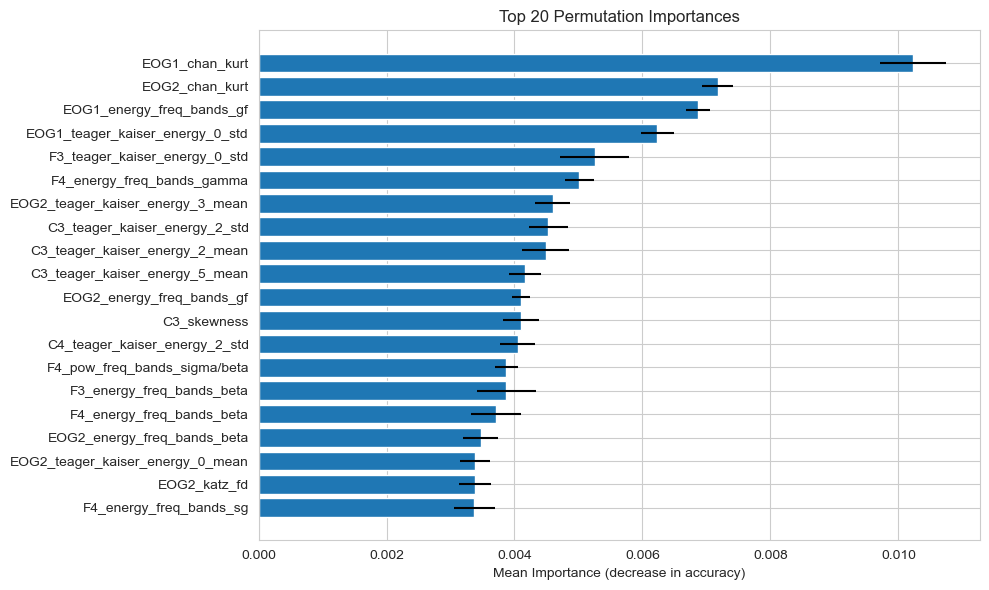

In [10]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Fit model on full dataset (or optionally use the last fold)
model = xgb.XGBClassifier()
model.fit(shaked_x_feat, y_shaked)

# Run permutation importance
r = permutation_importance(model, shaked_x_feat, y_shaked, n_repeats=10, random_state=42, scoring='accuracy')

# Extract results into a DataFrame
perm_importance = pd.DataFrame({
    'feature': shaked_x_feat.columns,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values(by='importance_mean', ascending=False)

#save
perm_importance.to_csv('figures/permutation_importance_shaked_all.csv', index=False)

# Show top 20
top20 = perm_importance.head(20)
print(top20)

# Optional: plot
plt.figure(figsize=(10, 6))
plt.barh(top20['feature'][::-1], top20['importance_mean'][::-1], xerr=top20['importance_std'][::-1])
plt.xlabel('Mean Importance (decrease in accuracy)')
plt.title('Top 20 Permutation Importances')
plt.tight_layout()
plt.show()



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


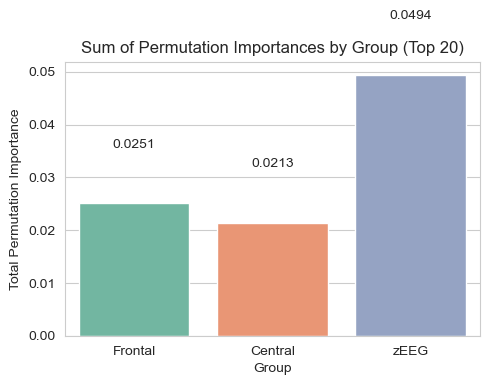

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add group labels to top20 permutation features
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
top20['group'] = top20['feature'].str[0].map(group_labels)

# Sum permutation importance by group
perm_group_sums = (
    top20.groupby('group')['importance_mean']
    .sum()
    .reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)
)

# Plot permutation importance group sums
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=perm_group_sums.index, y=perm_group_sums.values, palette='Set2')

# Add value labels on top of bars
for i, v in enumerate(perm_group_sums.values):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)

plt.title('Sum of Permutation Importances by Group (Top 20)')
plt.xlabel('Group')
plt.ylabel('Total Permutation Importance')
plt.tight_layout()
plt.show()



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


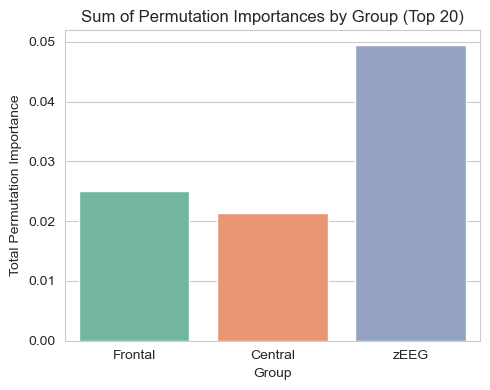

In [52]:
import seaborn as sns
# Add group labels to top20 permutation features
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
top20['group'] = top20['feature'].str[0].map(group_labels)

# Sum permutation importance by group
perm_group_sums = top20.groupby('group')['importance_mean'].sum().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Plot permutation importance group sums
plt.figure(figsize=(5, 4))
sns.barplot(x=perm_group_sums.index, y=perm_group_sums.values, palette='Set2')
plt.title('Sum of Permutation Importances by Group (Top 20)')
plt.xlabel('Group')
plt.ylabel('Total Permutation Importance')
plt.tight_layout()
plt.show()


In [53]:
perm_importance.to_csv('figures/permutation_importance_shaked_b.csv', index=False)

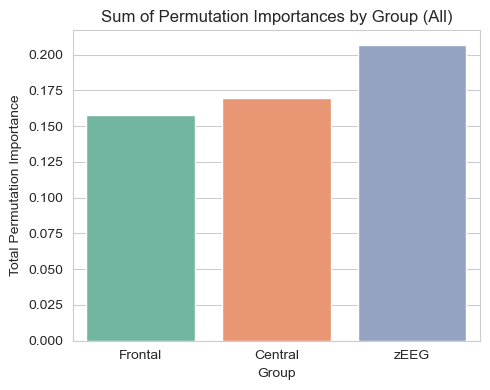

In [54]:
# Add group labels to top20 permutation features
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
perm_importance['group'] = perm_importance['feature'].str[0].map(group_labels)

# Sum permutation importance by group
perm_group_sums = perm_importance.groupby('group')['importance_mean'].sum().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Plot permutation importance group sums
plt.figure(figsize=(5, 4))
sns.barplot(x=perm_group_sums.index, y=perm_group_sums.values, palette='Set2')
plt.title('Sum of Permutation Importances by Group (All)')
plt.xlabel('Group')
plt.ylabel('Total Permutation Importance')
plt.tight_layout()
plt.show()


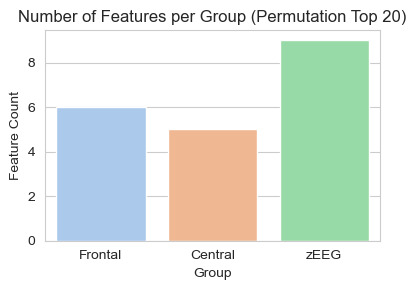

In [55]:
# Count number of features per group
perm_group_counts = top20['group'].value_counts().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Plot feature counts per group
plt.figure(figsize=(4, 3))
sns.barplot(x=perm_group_counts.index, y=perm_group_counts.values, palette='pastel')
plt.title('Number of Features per Group (Permutation Top 20)')
plt.ylabel('Feature Count')
plt.xlabel('Group')
plt.tight_layout()
plt.show()


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
      accuracy  precision  sensitivity  specificity        f1    ROCAUC  \
0     0.703503   0.699054     0.714679     0.692327  0.706780  0.775781   
1     0.704587   0.701627     0.711927     0.697248  0.706740  0.779508   
2     0.702544   0.697809     0.714512     0.690575  0.706062  0.775351   
3     0.700321   0.699303     0.702919     0.697723  0.701106  0.770441   
4     0.700571   0.700492     0.700726     0.700417  0.700609  0.776496   
mean  0.702305   0.699657     0.708952     0.695658  0.704259  0.775515   

         PRAUC  
0     0.774234  
1     0.776929  
2     0.769314  
3     0.762286  
4     0.775254  
mean  0.771604  


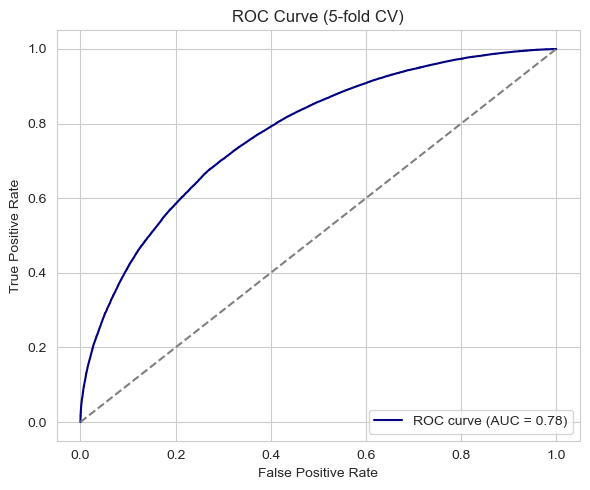

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize metrics dictionary and containers for ROC
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}
all_y_true = []
all_y_prob = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(shaked_x_feat, y_shaked):
    print(f'Fold {i}')
    i += 1
    model = XGBClassifier()
    x_train_fold, x_test_fold = shaked_x_feat.iloc[train_index], shaked_x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y_shaked[train_index], y_shaked[test_index]

    model.fit(x_train_fold, y_train_fold)

    y_prob = model.predict_proba(x_test_fold)[:, 1]  # probabilities for class 1
    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test_fold

    # Save for ROC
    all_y_true.extend(y_true)
    all_y_prob.extend(y_prob)

    # Save metrics
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_prob))
    metrics['PRAUC'].append(average_precision_score(y_true, y_prob))

# Print results
results = pd.DataFrame(metrics)
results.loc['mean'] = results.mean()
print(results)

# --- Plot ROC Curve ---
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_score = roc_auc_score(all_y_true, all_y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})', color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (5-fold CV)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True)
plt.show()


In [45]:
import pandas as pd

# Save FPR, TPR, and AUC to a CSV file
roc_df = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr
})
roc_df.to_csv('figures/roc_shaked_b3000.csv', index=False)

# Save AUC separately (optional but useful)
with open('figures/roc_shaked_b3000.txt', 'w') as f:
    f.write(f'{auc_score:.4f}')

In [46]:
shaked_x_b, shaked_y_b = rus.fit_resample(shaked_x_raw, shaked_y_raw)
y_shaked = shaked_y_b
shaked_x_feat = shaked_x_b.dropna(axis=1).drop(columns='subj')
# train model on shaked data
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix)
from xgboost import XGBClassifier
import pandas as pd

# Initialize metrics dictionary
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(shaked_x_feat, y_shaked):
    print(f'Fold {i}')
    i += 1
    model = XGBClassifier()
    x_train_fold, x_test_fold = shaked_x_feat.iloc[train_index], shaked_x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y_shaked[train_index], y_shaked[test_index]
    model.fit(x_train_fold, y_train_fold)
    y_pred = model.predict(x_test_fold)
    y_true = y_test_fold
    # save scores in dict
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_pred))
    metrics['PRAUC'].append(average_precision_score(y_true, y_pred))

# Print results as DataFrame
results = pd.DataFrame(metrics)
# Add mean row
results.loc['mean'] = results.mean()
print(results)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
      accuracy  precision  sensitivity  specificity        f1    ROCAUC  \
0     0.762642   0.747455     0.793320     0.731964  0.769705  0.762642   
1     0.765551   0.751119     0.794279     0.736823  0.772096  0.765551   
2     0.763931   0.749894     0.792025     0.735837  0.770384  0.763931   
3     0.764954   0.749043     0.796905     0.733002  0.772233  0.764954   
4     0.763076   0.747991     0.793491     0.732661  0.770069  0.763076   
mean  0.764031   0.749100     0.794004     0.734057  0.770898  0.764031   

         PRAUC  
0     0.696310  
1     0.699457  
2     0.697923  
3     0.698465  
4     0.696778  
mean  0.697787  


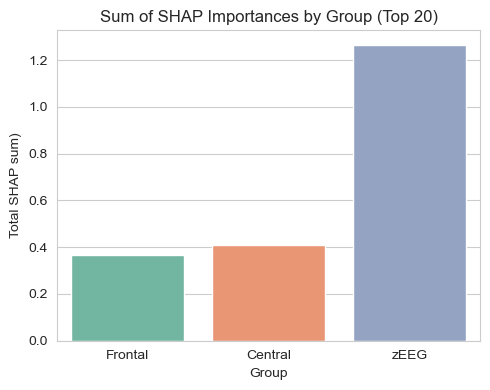

In [48]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_fold)

# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = x_test_fold.columns

# Create DataFrame and sort by importance
shap_importance = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap})
shap_importance = shap_importance.sort_values(by='mean_abs_shap', ascending=False).head(20)

# Map first letters to group names
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
shap_importance['group'] = shap_importance['feature'].str[0].map(group_labels)

# Sum SHAP values per group
group_sums = shap_importance.groupby('group')['mean_abs_shap'].sum().reindex(['Frontal', 'Central', 'zEEG'], fill_value=0)

# Bar plot of SHAP sums per group
plt.figure(figsize=(5, 4))
sns.barplot(x=group_sums.index, y=group_sums.values, palette='Set2')
plt.title('Sum of SHAP Importances by Group (Top 20)')
plt.xlabel('Group')
plt.ylabel('Total SHAP sum)')
plt.tight_layout()
plt.show()


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
      accuracy  precision  sensitivity  specificity        f1    ROCAUC  \
0     0.762642   0.747455     0.793320     0.731964  0.769705  0.848455   
1     0.765551   0.751119     0.794279     0.736823  0.772096  0.850634   
2     0.763931   0.749894     0.792025     0.735837  0.770384  0.849847   
3     0.764954   0.749043     0.796905     0.733002  0.772233  0.849799   
4     0.763076   0.747991     0.793491     0.732661  0.770069  0.848411   
mean  0.764031   0.749100     0.794004     0.734057  0.770898  0.849429   

         PRAUC  
0     0.838221  
1     0.840824  
2     0.839799  
3     0.838608  
4     0.838092  
mean  0.839109  


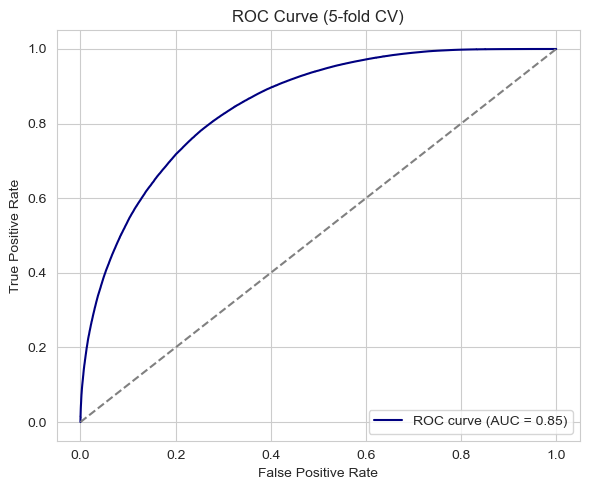

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize metrics dictionary and containers for ROC
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}
all_y_true = []
all_y_prob = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
i = 1
for train_index, test_index in kf.split(shaked_x_feat, y_shaked):
    print(f'Fold {i}')
    i += 1
    model = XGBClassifier()
    x_train_fold, x_test_fold = shaked_x_feat.iloc[train_index], shaked_x_feat.iloc[test_index]
    y_train_fold, y_test_fold = y_shaked[train_index], y_shaked[test_index]

    model.fit(x_train_fold, y_train_fold)

    y_prob = model.predict_proba(x_test_fold)[:, 1]  # probabilities for class 1
    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test_fold

    # Save for ROC
    all_y_true.extend(y_true)
    all_y_prob.extend(y_prob)

    # Save metrics
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred))
    metrics['sensitivity'].append(recall_score(y_true, y_pred))
    metrics['f1'].append(f1_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics['specificity'].append(tn / (tn + fp))
    metrics['ROCAUC'].append(roc_auc_score(y_true, y_prob))
    metrics['PRAUC'].append(average_precision_score(y_true, y_prob))

# Print results
results = pd.DataFrame(metrics)
results.loc['mean'] = results.mean()
print(results)

# --- Plot ROC Curve ---
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_score = roc_auc_score(all_y_true, all_y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})', color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (5-fold CV)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True)
plt.show()


In [50]:
# Save FPR, TPR, and AUC to a CSV file
roc_df = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr
})
roc_df.to_csv('figures/roc_shaked_bmax.csv', index=False)

# Save AUC separately (optional but useful)
with open('figures/roc_shaked_bmax.txt', 'w') as f:
    f.write(f'{auc_score:.4f}')

In [65]:
# per subj top 20
from xgboost import XGBClassifier
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler


shaked_x_b, shaked_y_b = rus.fit_resample(shaked_x_raw, shaked_y_raw)
y_shaked = shaked_y_b
shaked_x_feat = shaked_x_b.dropna(axis=1).drop(columns='subj')
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}

# הכנה
all_subjects = shaked_x_b['subj'].unique()
subject_level_data = []

for subj in all_subjects:
    print(f"Processing subject: {subj}")
    
    # סינון הנתונים של אותו נבדק
    subj_mask = shaked_x_b['subj'] == subj
    x_subj = shaked_x_feat.loc[subj_mask]
    y_subj = y_shaked[subj_mask]

    # קיפוץ אם יש מעט מדי דגימות
    if len(x_subj) < 10 or len(np.unique(y_subj)) < 2:
        continue


    # אימון מודל
    model = XGBClassifier()
    model.fit(x_subj, y_subj)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_subj)

    # ממוצע מוחלט של ערכי SHAP
    mean_shap = np.abs(shap_values).mean(axis=0)
    feature_names = x_subj.columns
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap
    })
    top20 = shap_importance.sort_values(by='mean_abs_shap', ascending=False).head(20)

    # שיוך קבוצתי לפי אות ראשונה
    top20['group'] = top20['feature'].str[0].map(group_labels)

    # חישוב כמות וסכום SHAP לפי קבוצה
    row = {'subj': subj}
    for group in ['Frontal', 'Central', 'zEEG']:
        group_feats = top20[top20['group'] == group]
        row[f'count_{group}'] = len(group_feats)
        row[f'shap_sum_{group}'] = group_feats['mean_abs_shap'].sum()
    
    subject_level_data.append(row)

# בניית טבלה
subject_shap_df = pd.DataFrame(subject_level_data)
# save to csv
subject_shap_df.to_csv('figures/subject_shap_summary_top20_nosplit.csv', index=False)
display(subject_shap_df)


Processing subject: 44
Processing subject: 735
Processing subject: 39
Processing subject: 38
Processing subject: 51
Processing subject: 723
Processing subject: 731
Processing subject: 713
Processing subject: 715
Processing subject: 752
Processing subject: 47
Processing subject: 55
Processing subject: 54
Processing subject: 737
Processing subject: 53
Processing subject: 46
Processing subject: 714
Processing subject: 744
Processing subject: 733
Processing subject: 734
Processing subject: 724
Processing subject: 746
Processing subject: 59
Processing subject: 56


,subj,count_Frontal,shap_sum_Frontal,count_Central,shap_sum_Central,count_zEEG,shap_sum_zEEG
0,44,7,0.511086,7,0.584281,6,0.429843
1,735,2,0.085946,9,0.631583,9,0.460290
2,39,11,0.774030,9,0.596138,0,0.000000
3,38,7,0.471240,6,0.353273,7,0.515324
4,51,2,0.241839,3,0.238216,15,2.253332
5,723,3,0.495354,8,0.602952,9,0.893172
6,731,2,0.186540,10,0.945931,8,0.799943
7,713,3,0.144096,4,0.280945,13,1.377266
8,715,1,0.069101,2,0.152736,17,1.720645
9,752,7,0.741189,7,0.971155,6,0.804822


In [68]:
# per subj top 30
from xgboost import XGBClassifier
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler


shaked_x_b, shaked_y_b = rus.fit_resample(shaked_x_raw, shaked_y_raw)
y_shaked = shaked_y_b
shaked_x_feat = shaked_x_b.dropna(axis=1).drop(columns='subj')
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}

# הכנה
all_subjects = shaked_x_b['subj'].unique()
subject_level_data = []

for subj in all_subjects:
    print(f"Processing subject: {subj}")
    
    # סינון הנתונים של אותו נבדק
    subj_mask = shaked_x_b['subj'] == subj
    x_subj = shaked_x_feat.loc[subj_mask]
    y_subj = y_shaked[subj_mask]

    # קיפוץ אם יש מעט מדי דגימות
    if len(x_subj) < 10 or len(np.unique(y_subj)) < 2:
        continue


    # אימון מודל
    model = XGBClassifier()
    model.fit(x_subj, y_subj)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_subj)

    # ממוצע מוחלט של ערכי SHAP
    mean_shap = np.abs(shap_values).mean(axis=0)
    feature_names = x_subj.columns
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap
    })
    top20 = shap_importance.sort_values(by='mean_abs_shap', ascending=False).head(30)

    # שיוך קבוצתי לפי אות ראשונה
    top20['group'] = top20['feature'].str[0].map(group_labels)

    # חישוב כמות וסכום SHAP לפי קבוצה
    row = {'subj': subj}
    for group in ['Frontal', 'Central', 'zEEG']:
        group_feats = top20[top20['group'] == group]
        row[f'count_{group}'] = len(group_feats)
        row[f'shap_sum_{group}'] = group_feats['mean_abs_shap'].sum()
    
    subject_level_data.append(row)

# בניית טבלה
subject_shap_df = pd.DataFrame(subject_level_data)
# save to csv
subject_shap_df.to_csv('figures/subject_shap_summary_top30_nosplit.csv', index=False)
display(subject_shap_df)


Processing subject: 44
Processing subject: 735
Processing subject: 39
Processing subject: 38
Processing subject: 51
Processing subject: 723
Processing subject: 731
Processing subject: 713
Processing subject: 715
Processing subject: 752
Processing subject: 47
Processing subject: 55
Processing subject: 54
Processing subject: 737
Processing subject: 53
Processing subject: 46
Processing subject: 714
Processing subject: 744
Processing subject: 733
Processing subject: 734
Processing subject: 724
Processing subject: 746
Processing subject: 59
Processing subject: 56


,subj,count_Frontal,shap_sum_Frontal,count_Central,shap_sum_Central,count_zEEG,shap_sum_zEEG
0,44,11,0.721430,12,0.839276,7,0.480819
1,735,5,0.193901,14,0.812697,11,0.527259
2,39,14,0.907301,13,0.771480,3,0.129624
3,38,8,0.509052,11,0.567517,11,0.676097
4,51,4,0.363494,5,0.363543,21,2.629601
5,723,6,0.631552,11,0.736459,13,1.086913
6,731,4,0.266338,16,1.183756,10,0.880261
7,713,8,0.341722,6,0.359100,16,1.499590
8,715,2,0.113273,5,0.294678,23,2.014354
9,752,12,1.011616,12,1.254615,6,0.804822


In [66]:
# per subj all
# per subj – all features (no top-20), sum only
from xgboost import XGBClassifier
import shap
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler

# הנחה: rus, shaked_x_raw, shaked_y_raw קיימים כמו אצלך
shaked_x_b, shaked_y_b = rus.fit_resample(shaked_x_raw, shaked_y_raw)
y_shaked = shaked_y_b

# שומרים את עמודת הנבדק ומסירים אותה ממטריצת הפיצ'רים
all_subjects = shaked_x_b['subj'].unique()
shaked_x_feat = shaked_x_b.dropna(axis=1).drop(columns='subj')

# מיפוי קבוצות לפי האות הראשונה בשם הפיצ'ר
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}

def compute_mean_abs_shap(model, X):
    """מחזיר וקטור mean(|SHAP|) לכל פיצ'ר, עמיד לבינארי/רב־מחלקתי."""
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X)
    # sv יכול להיות:
    # 1) np.ndarray בצורה (n_samples, n_features) – בינארי בגרסאות מסוימות
    # 2) list של מערכים לכל מחלקה – לעיתים ב־XGBClassifier
    if isinstance(sv, list):
        if len(sv) == 2:
            # בינארי: משתמשים במחלקה החיובית (מקובל)
            sv_arr = sv[1]
        else:
            # רב־מחלקתי: ממוצע על פני המחלקות
            sv_arr = np.stack(sv, axis=0).mean(axis=0)
    else:
        sv_arr = sv
    return np.abs(sv_arr).mean(axis=0)  # ממוצע על פני הדגימות, מוחלט

subject_level_rows = []

for subj in all_subjects:
    print(f"Processing subject: {subj}")

    # סינון הנתונים של הנבדק
    subj_mask = shaked_x_b['subj'] == subj
    x_subj = shaked_x_feat.loc[subj_mask]
    y_subj = y_shaked[subj_mask]

    # דילוג אם מעט מדי דגימות או מחלקה אחת
    if len(x_subj) < 10 or len(np.unique(y_subj)) < 2:
        continue

    # אימון מודל
    model = XGBClassifier()
    model.fit(x_subj, y_subj)

    # חישוב mean(|SHAP|) לכל פיצ'ר
    mean_shap = compute_mean_abs_shap(model, x_subj)
    feature_names = x_subj.columns

    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap
    })

    # שיוך קבוצה לכל פיצ'ר לפי האות הראשונה
    shap_importance['group'] = shap_importance['feature'].str[0].map(group_labels)

    # סכום SHAP לפי קבוצה – **עבור כל הפיצ'רים**, בלי חיתוך ל־top-20
    sums = shap_importance.groupby('group', dropna=False)['mean_abs_shap'].sum()

    # בניית שורה לרמת הנבדק – רק סכומים
    row = {'subj': subj}
    for g in ['Frontal', 'Central', 'zEEG']:
        row[f'shap_sum_{g}'] = float(sums.get(g, 0.0))
    subject_level_rows.append(row)

# טבלת סיכום לרמת הנבדק
subject_shap_df = pd.DataFrame(subject_level_rows)

# שמירה
out_path = 'figures/subject_shap_summary_ALL_nosplit.csv'
subject_shap_df.to_csv(out_path, index=False)

# הצצה
display(subject_shap_df)

Processing subject: 44
Processing subject: 735
Processing subject: 39
Processing subject: 38
Processing subject: 51
Processing subject: 723
Processing subject: 731
Processing subject: 713
Processing subject: 715
Processing subject: 752
Processing subject: 47
Processing subject: 55
Processing subject: 54
Processing subject: 737
Processing subject: 53
Processing subject: 46
Processing subject: 714
Processing subject: 744
Processing subject: 733
Processing subject: 734
Processing subject: 724
Processing subject: 746
Processing subject: 59
Processing subject: 56


,subj,shap_sum_Frontal,shap_sum_Central,shap_sum_zEEG
0,44,3.376451,3.629833,3.211122
1,735,2.109843,2.536196,2.318086
2,39,3.417876,3.223839,2.607065
3,38,2.824380,2.769904,3.106470
4,51,3.339275,3.194706,5.680357
5,723,2.423158,2.549275,3.020677
6,731,2.163080,3.093944,2.744417
7,713,2.111649,2.000820,3.622046
8,715,1.974872,2.291863,4.294501
9,752,3.997082,4.232341,3.632579


In [20]:
for subj in all_subjects:
    print(f"Processing subject: {subj}")
    
    # סינון הנתונים של אותו נבדק
    subj_mask = shaked_x_b['subj'] == subj
    x_subj = shaked_x_feat.loc[subj_mask]
    y_subj = y_shaked[subj_mask]
    # print ratio
    print(f"Subject {subj} has {len(x_subj)} samples, ratio of positive to negative: {np.sum(y_subj) / len(y_subj):.2f}")

Processing subject: 44
Subject 44 has 15545 samples, ratio of positive to negative: 0.18
Processing subject: 735
Subject 735 has 39841 samples, ratio of positive to negative: 0.76
Processing subject: 39
Subject 39 has 10817 samples, ratio of positive to negative: 0.48
Processing subject: 38
Subject 38 has 17530 samples, ratio of positive to negative: 0.25
Processing subject: 51
Subject 51 has 14962 samples, ratio of positive to negative: 0.24
Processing subject: 723
Subject 723 has 25582 samples, ratio of positive to negative: 0.55
Processing subject: 731
Subject 731 has 38640 samples, ratio of positive to negative: 0.80
Processing subject: 713
Subject 713 has 36616 samples, ratio of positive to negative: 0.77
Processing subject: 715
Subject 715 has 18930 samples, ratio of positive to negative: 0.45
Processing subject: 752
Subject 752 has 14665 samples, ratio of positive to negative: 0.44
Processing subject: 47
Subject 47 has 12349 samples, ratio of positive to negative: 0.00
Processin

In [22]:
# original features (before balancing everything)
x_full = shaked_x_raw.dropna(axis=1).drop(columns='subj')
y_full = shaked_y_raw
subj_series = shaked_x_raw['subj']  # subj info

# prep
group_labels = {'F': 'Frontal', 'C': 'Central', 'E': 'zEEG'}
subject_level_data = []

for subj in subj_series.unique():
    print(f"Processing subject: {subj}")
    
    # Get subject data
    subj_mask = subj_series == subj
    x_subj_raw = x_full.loc[subj_mask].copy()
    y_subj_raw = y_full[subj_mask]

    # Skip if too few samples or only one class
    if len(x_subj_raw) < 10 or len(np.unique(y_subj_raw)) < 2:
        continue

    # Balance this subject's data
    rus = RandomUnderSampler(random_state=42)
    x_bal, y_bal = rus.fit_resample(x_subj_raw, y_subj_raw)

    # Split into train/test
    x_train, x_test, y_train, y_test = train_test_split(
        x_bal, y_bal, test_size=0.4, random_state=42, stratify=y_bal)

    # Train model
    model = XGBClassifier()
    model.fit(x_train, y_train)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_test)

    # SHAP summary
    mean_shap = np.abs(shap_values).mean(axis=0)
    feature_names = x_test.columns
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap
    })
    top20 = shap_importance.sort_values(by='mean_abs_shap', ascending=False).head(20)
    top20['group'] = top20['feature'].str[0].map(group_labels)

    # Collect stats
    row = {'subj': subj}
    for group in ['Frontal', 'Central', 'zEEG']:
        group_feats = top20[top20['group'] == group]
        row[f'count_{group}'] = len(group_feats)
        row[f'shap_sum_{group}'] = group_feats['mean_abs_shap'].sum()
    
    subject_level_data.append(row)

# Final DataFrame
subject_shap_df = pd.DataFrame(subject_level_data)
subject_shap_df.to_csv('figures/subject_shap_summary_balanced_per_subj.csv', index=False)
display(subject_shap_df)

Processing subject: 38
Processing subject: 39
Processing subject: 44
Processing subject: 46
Processing subject: 47
Processing subject: 51
Processing subject: 53
Processing subject: 54
Processing subject: 55
Processing subject: 56
Processing subject: 59
Processing subject: 713
Processing subject: 714
Processing subject: 715
Processing subject: 723
Processing subject: 724
Processing subject: 731
Processing subject: 733
Processing subject: 734
Processing subject: 735
Processing subject: 737
Processing subject: 744
Processing subject: 746
Processing subject: 752


,subj,count_Frontal,shap_sum_Frontal,count_Central,shap_sum_Central,count_zEEG,shap_sum_zEEG
0,38,7,0.558978,6,0.473170,7,0.620632
1,39,9,0.677540,8,0.668674,3,0.207859
2,44,6,0.591604,6,0.616081,8,0.864308
3,46,10,3.472752,5,1.376333,5,0.996234
4,47,7,1.819581,5,0.729976,8,2.340749
5,51,5,0.547258,2,0.220296,13,2.712971
6,53,2,0.313399,13,2.288551,5,1.074675
7,54,3,0.186673,2,0.125426,15,1.324630
8,55,5,0.461119,5,0.372398,10,0.820993
9,56,4,0.524841,10,2.297609,6,3.711467


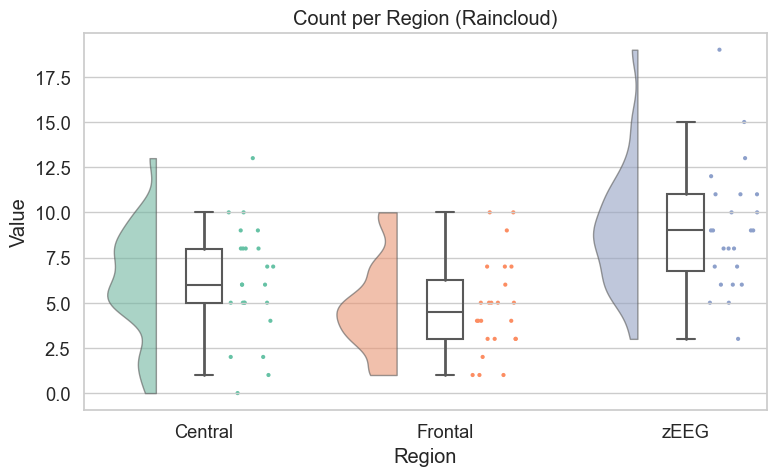

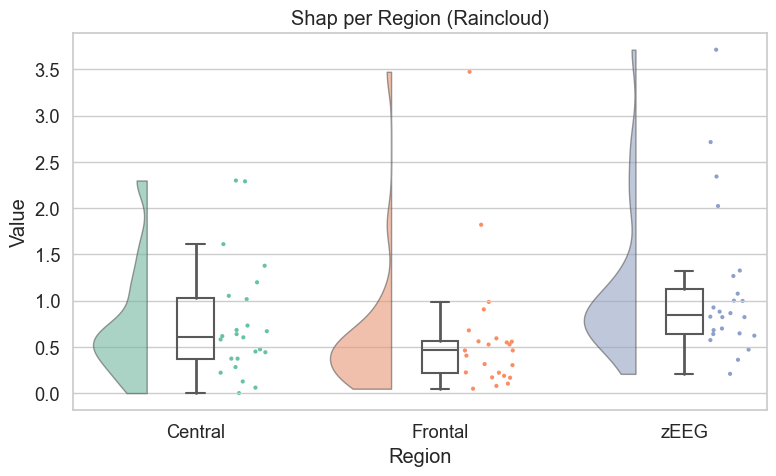

In [25]:
import ptitprince as pt

# הגדרות כלליות
sns.set(style="whitegrid", font_scale=1.2)
region_order = ['Central', 'Frontal', 'zEEG']
metric_order = ['count', 'shap']

# יצירת גרפים לכל metric_type
for metric in metric_order:
    data_subset = df_long[df_long['metric_type'] == metric]

    # ציור ה-raincloud plot
    f, ax = plt.subplots(figsize=(8, 5))

    pt.RainCloud(
        x='region',
        y='value',
        data=data_subset,
        order=region_order,
        palette='Set2',
        bw=.3,
        width_viol=.5,
        ax=ax,
        orient='v',
        move=0.2,
        alpha=0.6,
        # pointplot=True,
        box_showfliers=False
    )

    ax.set_title(f"{metric.capitalize()} per Region (Raincloud)")
    ax.set_ylabel("Value")
    ax.set_xlabel("Region")
    plt.tight_layout()
    plt.show()


   accuracy                                          precision  \
C  0.733806  [0.5019738671114818, 0.502169318055401, 0.5027...   
F  0.728190  [0.5019738671114818, 0.5020855347311051, 0.502...   
E  0.733278  [0.5019738671114818, 0.5020855347311051, 0.502...   

                                         sensitivity  \
C  [1.0, 1.0, 1.0, 0.9999446167478955, 0.99972308...   
F  [1.0, 1.0, 1.0, 0.9999446167478955, 0.99994461...   
E  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999446167478...   

                                         specificity        f1    ROCAUC  \
C  [0.0, 0.0, 0.0, 5.5383252104523883e-05, 0.0002...  0.732893  0.830106   
F  [0.0, 0.0, 0.0, 5.5383252104523883e-05, 5.5383...  0.725866  0.826137   
E  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.5383252104523...  0.730536  0.830473   

      PRAUC  
C  0.847239  
F  0.844735  
E  0.848413  


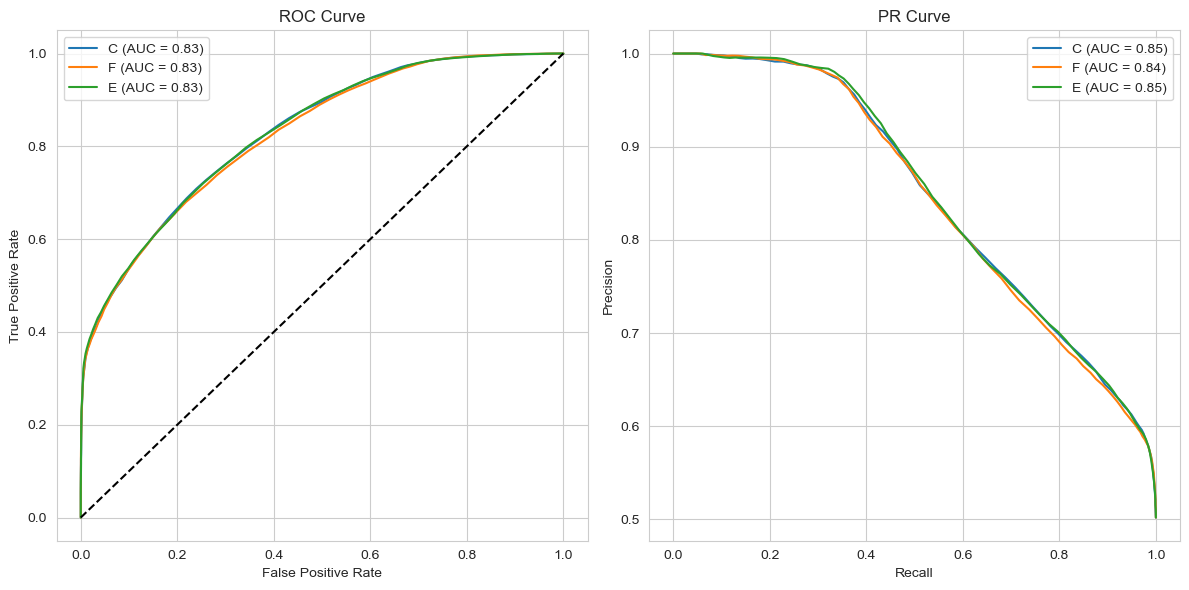

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier  # אפשר לשנות את המודל כראות עיניך

# נניח ש- shaked_x_feat הוא הדאטהפריים שלך
# נעשה פילטר לפיצ'רים עם התחיליות C, F ו-E
X_C = shaked_x_feat.filter(like='C', axis=1)
X_F = shaked_x_feat.filter(like='F', axis=1)
X_E = shaked_x_feat.filter(like='E', axis=1)

# נניח שיש לך גם טאגים או תוויות
y = y_shaked  

# חיצוץ הנתונים לסט אימון וסט בדיקה
X_C_train, X_C_test, y_train, y_test = train_test_split(X_C, y, test_size=0.3, random_state=42)
X_F_train, X_F_test, _, _ = train_test_split(X_F, y, test_size=0.3, random_state=42)
X_E_train, X_E_test, _, _ = train_test_split(X_E, y, test_size=0.3, random_state=42)

# יצירת מודלים
model_C = RandomForestClassifier()  
model_F = RandomForestClassifier()  
model_E = RandomForestClassifier()  

# אילו מטריקות אנחנו שומרים
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}

# אימון כל מודל והערכת המטריקות
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # חישוב המטריקות
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    return accuracy, precision, recall, f1, roc_auc, pr_auc, y_prob

# מודל C
acc_C, prec_C, recall_C, f1_C, roc_auc_C, pr_auc_C, prob_C = train_and_evaluate(model_C, X_C_train, X_C_test, y_train, y_test)
metrics['accuracy'].append(acc_C)
metrics['precision'].append(prec_C)
metrics['sensitivity'].append(recall_C)
metrics['specificity'].append(1 - recall_C)  # specificity = 1 - recall
metrics['f1'].append(f1_C)
metrics['ROCAUC'].append(roc_auc_C)
metrics['PRAUC'].append(pr_auc_C)

# מודל F
acc_F, prec_F, recall_F, f1_F, roc_auc_F, pr_auc_F, prob_F = train_and_evaluate(model_F, X_F_train, X_F_test, y_train, y_test)
metrics['accuracy'].append(acc_F)
metrics['precision'].append(prec_F)
metrics['sensitivity'].append(recall_F)
metrics['specificity'].append(1 - recall_F)
metrics['f1'].append(f1_F)
metrics['ROCAUC'].append(roc_auc_F)
metrics['PRAUC'].append(pr_auc_F)

# מודל E
acc_E, prec_E, recall_E, f1_E, roc_auc_E, pr_auc_E, prob_E = train_and_evaluate(model_E, X_E_train, X_E_test, y_train, y_test)
metrics['accuracy'].append(acc_E)
metrics['precision'].append(prec_E)
metrics['sensitivity'].append(recall_E)
metrics['specificity'].append(1 - recall_E)
metrics['f1'].append(f1_E)
metrics['ROCAUC'].append(roc_auc_E)
metrics['PRAUC'].append(pr_auc_E)

# הצגת המטריקות
print(pd.DataFrame(metrics, index=['C', 'F', 'E']))

# ציור גרפים של ROC ו-PR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# ROC
fpr_C, tpr_C, _ = roc_curve(y_test, prob_C)
fpr_F, tpr_F, _ = roc_curve(y_test, prob_F)
fpr_E, tpr_E, _ = roc_curve(y_test, prob_E)

ax1.plot(fpr_C, tpr_C, label='C (AUC = {:.2f})'.format(roc_auc_C))
ax1.plot(fpr_F, tpr_F, label='F (AUC = {:.2f})'.format(roc_auc_F))
ax1.plot(fpr_E, tpr_E, label='E (AUC = {:.2f})'.format(roc_auc_E))
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# PR Curve
ax2.plot(recall_C, prec_C, label='C (AUC = {:.2f})'.format(pr_auc_C))
ax2.plot(recall_F, prec_F, label='F (AUC = {:.2f})'.format(pr_auc_F))
ax2.plot(recall_E, prec_E, label='E (AUC = {:.2f})'.format(pr_auc_E))
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR Curve')
ax2.legend()

plt.tight_layout()
plt.show()


Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


   accuracy  precision  sensitivity  specificity        f1    ROCAUC     PRAUC
C  0.604283   0.609815     0.502137     0.497863  0.509487  0.672255  0.658395
F  0.617854   0.622921     0.535305     0.464695  0.549272  0.684942  0.671472
E  0.585950   0.603044     0.468938     0.531062  0.478471  0.641593  0.632837


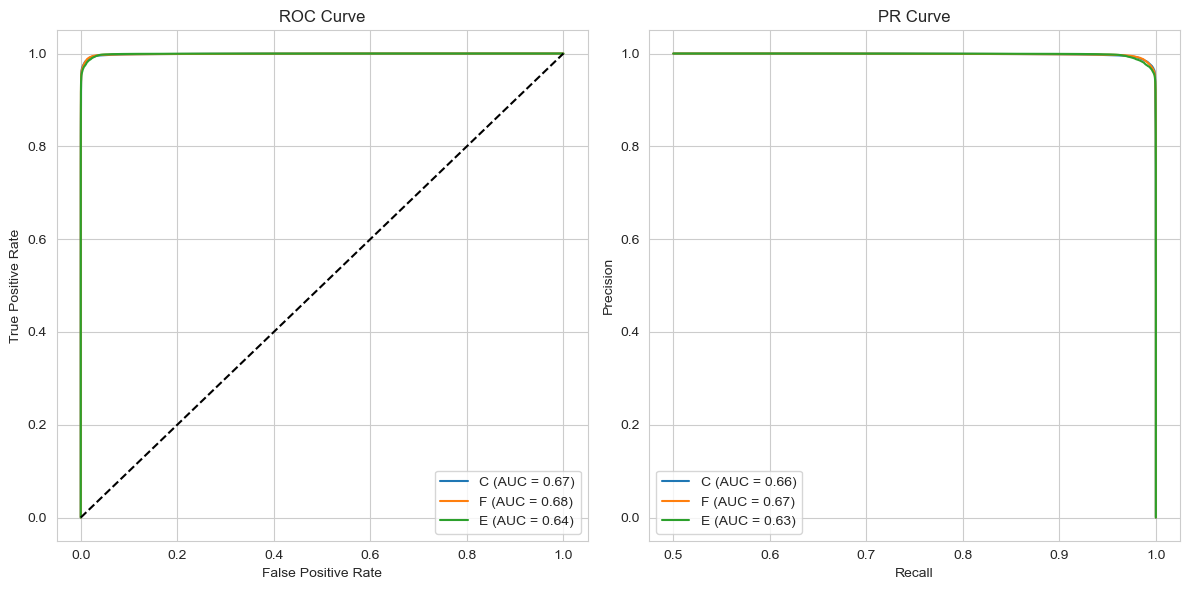

In [9]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# נניח ש- x_shaked הוא הדאטהפריים שלך ו-y_shaked הוא המערך עם התוויות
# נעשה פילטר לפיצ'רים עם התחיליות C, F ו-E
X_C = x_shaked.filter(like='C', axis=1)
X_F = x_shaked.filter(like='F', axis=1)
X_E = x_shaked.filter(like='E', axis=1)

# y_shaked הוא מערך התוויות שלך
y = y_shaked

# נשתמש בעמודת subj כדי לקבוע את הקבוצות של LOO
groups = x_shaked['subj']  # המזהים של הנבדקים

# אילו מטריקות אנחנו שומרים
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'ROCAUC': [], 'PRAUC': []}

# הגדרת Leave-One-Group-Out
logo = LeaveOneGroupOut()

# אימון והערכה עבור מודל אחד
def logo_cv_evaluation(X, y, model, groups):
    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    roc_auc_list = []
    pr_auc_list = []
    
    # עבור כל חיתוך של LOO (לפי מזהי נבדק)
    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # אימון המודל
        model.fit(X_train, y_train)
        
        # חיזוי על הדגימה
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # חישוב המטריקות
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_curve, precision_curve)
        
        # שמירת המטריקות
        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        roc_auc_list.append(roc_auc)
        pr_auc_list.append(pr_auc)
    
    # חישוב ממוצעים עבור כל המטריקות
    return {
        'accuracy': np.mean(accuracy_list),
        'precision': np.mean(precision_list),
        'sensitivity': np.mean(recall_list),
        'specificity': np.mean([1 - r for r in recall_list]),  # specificity = 1 - sensitivity
        'f1': np.mean(f1_list),
        'ROCAUC': np.mean(roc_auc_list),
        'PRAUC': np.mean(pr_auc_list)
    }

# מודל C
model_C = XGBClassifier()
metrics_C = logo_cv_evaluation(X_C, y, model_C, groups)
metrics['accuracy'].append(metrics_C['accuracy'])
metrics['precision'].append(metrics_C['precision'])
metrics['sensitivity'].append(metrics_C['sensitivity'])
metrics['specificity'].append(metrics_C['specificity'])
metrics['f1'].append(metrics_C['f1'])
metrics['ROCAUC'].append(metrics_C['ROCAUC'])
metrics['PRAUC'].append(metrics_C['PRAUC'])

# מודל F
model_F = XGBClassifier()
metrics_F = logo_cv_evaluation(X_F, y, model_F, groups)
metrics['accuracy'].append(metrics_F['accuracy'])
metrics['precision'].append(metrics_F['precision'])
metrics['sensitivity'].append(metrics_F['sensitivity'])
metrics['specificity'].append(metrics_F['specificity'])
metrics['f1'].append(metrics_F['f1'])
metrics['ROCAUC'].append(metrics_F['ROCAUC'])
metrics['PRAUC'].append(metrics_F['PRAUC'])

# מודל E
model_E = XGBClassifier()
metrics_E = logo_cv_evaluation(X_E, y, model_E, groups)
metrics['accuracy'].append(metrics_E['accuracy'])
metrics['precision'].append(metrics_E['precision'])
metrics['sensitivity'].append(metrics_E['sensitivity'])
metrics['specificity'].append(metrics_E['specificity'])
metrics['f1'].append(metrics_E['f1'])
metrics['ROCAUC'].append(metrics_E['ROCAUC'])
metrics['PRAUC'].append(metrics_E['PRAUC'])

# הצגת המטריקות
print(pd.DataFrame(metrics, index=['C', 'F', 'E']))

# ציור גרפים של ROC ו-PR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# ROC
fpr_C, tpr_C, _ = roc_curve(y, model_C.predict_proba(X_C)[:, 1])
fpr_F, tpr_F, _ = roc_curve(y, model_F.predict_proba(X_F)[:, 1])
fpr_E, tpr_E, _ = roc_curve(y, model_E.predict_proba(X_E)[:, 1])

ax1.plot(fpr_C, tpr_C, label='C (AUC = {:.2f})'.format(metrics_C['ROCAUC']))
ax1.plot(fpr_F, tpr_F, label='F (AUC = {:.2f})'.format(metrics_F['ROCAUC']))
ax1.plot(fpr_E, tpr_E, label='E (AUC = {:.2f})'.format(metrics_E['ROCAUC']))
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# PR Curve
recall_C, precision_C, _ = precision_recall_curve(y, model_C.predict_proba(X_C)[:, 1])
recall_F, precision_F, _ = precision_recall_curve(y, model_F.predict_proba(X_F)[:, 1])
recall_E, precision_E, _ = precision_recall_curve(y, model_E.predict_proba(X_E)[:, 1])

ax2.plot(recall_C, precision_C, label='C (AUC = {:.2f})'.format(metrics_C['PRAUC']))
ax2.plot(recall_F, precision_F, label='F (AUC = {:.2f})'.format(metrics_F['PRAUC']))
ax2.plot(recall_E, precision_E, label='E (AUC = {:.2f})'.format(metrics_E['PRAUC']))
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR Curve')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import numpy as np
import pandas as pd

# נניח ש- x_shaked הוא הדאטהפריים שלך ו-y_shaked הוא המערך עם התוויות
# נעשה פילטר לפיצ'רים עם התחיליות C, F ו-E
X_C = x_shaked.filter(like='C', axis=1)
X_F = x_shaked.filter(like='F', axis=1)
X_E = x_shaked.filter(like='E', axis=1)

# y_shaked הוא מערך התוויות שלך
y = y_shaked

# נשתמש בעמודת subj כדי לקבוע את הקבוצות של LOO
groups = x_shaked['subj']  # המזהים של הנבדקים

# פונקציה לחישוב המטריקות
def evaluate_model_for_subject(X, y, model):
    # אימון המודל
    model.fit(X, y)
    
    # חיזוי על הדגימה
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # חישוב המטריקות
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_prob)
    precision_curve, recall_curve, _ = precision_recall_curve(y, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    # החזרת המטריקות
    return {
        'accuracy': accuracy,
        'precision': precision,
        'sensitivity': recall,  # sensitivity = recall
        'specificity': 1 - recall,  # specificity = 1 - recall
        'f1': f1,
        'ROCAUC': roc_auc,
        'PRAUC': pr_auc
    }

# יצירת מילון שיאחסן את המטריקות לכל נבדק ומודל
metrics_per_subject = {}



# חישוב המטריקות עבור כל נבדק ו-3 המודלים
for subject_id in x_shaked['subj'].unique():
    # אתחול מודל XGB
    model_C = XGBClassifier()
    model_F = XGBClassifier()
    model_E = XGBClassifier()
    
    # חיתוך הנתונים עבור נבדק זה
    X_subj = x_shaked[x_shaked['subj'] == subject_id]
    y_subj = y_shaked[x_shaked['subj'] == subject_id]

    # חישוב המטריקות עבור כל מודל
    metrics_C = evaluate_model_for_subject(X_subj.filter(like='C', axis=1), y_subj, model_C)
    metrics_F = evaluate_model_for_subject(X_subj.filter(like='F', axis=1), y_subj, model_F)
    metrics_E = evaluate_model_for_subject(X_subj.filter(like='E', axis=1), y_subj, model_E)

    # שמירת התוצאות עבור הנבדק
    metrics_per_subject[subject_id] = {
        'C': metrics_C,
        'F': metrics_F,
        'E': metrics_E
    }

# המרת המידע למבנה נתונים מסודר (DataFrame) להשוואה נוחה
metrics_df = pd.DataFrame(columns=['accuracy', 'precision', 'sensitivity', 'specificity', 'f1', 'ROCAUC', 'PRAUC'])

for subject_id, models in metrics_per_subject.items():
    for model_name, metrics in models.items():
        metrics_df.loc[f'{subject_id}_{model_name}'] = metrics

# הצגת המטריקות
print(metrics_df)


In [69]:
import os
import pandas as pd
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# Directory to save individual subject permutation results
output_dir = './permutation_results'
os.makedirs(output_dir, exist_ok=True)

# original features (before balancing everything)
x_full = shaked_x_raw.dropna(axis=1).drop(columns='subj')
y_full = shaked_y_raw
subj_series = shaked_x_raw['subj']  # subj info

# Loop through each subject
for subj in subj_series.unique():
    print(f"Processing subject: {subj}")

    # Get subject data
    subj_mask = subj_series == subj
    x_subj_raw = x_full.loc[subj_mask].copy()
    y_subj_raw = y_full[subj_mask]

    # Skip if too few samples or only one class
    if len(x_subj_raw) < 10 or len(np.unique(y_subj_raw)) < 2:
        continue

    # Balance this subject's data
    rus = RandomUnderSampler(random_state=42)
    x_bal, y_bal = rus.fit_resample(x_subj_raw, y_subj_raw)

    # Train model
    model = XGBClassifier()
    model.fit(x_bal, y_bal)

    # Run permutation importance
    r = permutation_importance(model, x_bal, y_bal, n_repeats=10, random_state=42, scoring='accuracy')

    # Extract results into a DataFrame
    perm_importance = pd.DataFrame({
        'feature': x_bal.columns,
        'importance_mean': r.importances_mean,
        'importance_std': r.importances_std
    }).sort_values(by='importance_mean', ascending=False)

    # Save permutation results for this subject
    perm_importance.to_csv(os.path.join(output_dir, f'subject_{subj}_permutation_importance.csv'), index=False)

    print(f"Saved permutation importance for subject {subj} to {output_dir}/subject_{subj}_permutation_importance.csv")


Processing subject: 38
Saved permutation importance for subject 38 to ./permutation_results/subject_38_permutation_importance.csv
Processing subject: 39
Saved permutation importance for subject 39 to ./permutation_results/subject_39_permutation_importance.csv
Processing subject: 44
Saved permutation importance for subject 44 to ./permutation_results/subject_44_permutation_importance.csv
Processing subject: 46
Saved permutation importance for subject 46 to ./permutation_results/subject_46_permutation_importance.csv
Processing subject: 47
Saved permutation importance for subject 47 to ./permutation_results/subject_47_permutation_importance.csv
Processing subject: 51
Saved permutation importance for subject 51 to ./permutation_results/subject_51_permutation_importance.csv
Processing subject: 53
Saved permutation importance for subject 53 to ./permutation_results/subject_53_permutation_importance.csv
Processing subject: 54
Saved permutation importance for subject 54 to ./permutation_result

In [8]:
f = ['subj', 'epoch_id', 'app_entropy', 'decorr_time', 'energy_freq_bands_theta', 'energy_freq_bands_alpha',
         'energy_freq_bands_sigma', 'energy_freq_bands_beta', 'energy_freq_bands_gamma', 'energy_freq_bands_fast',
         'higuchi_fd', 'hjorth_complexity', 'hjorth_complexity_spect', 'hjorth_mobility', 'hjorth_mobility_spect',
         'hurst_exp', 'katz_fd', 'kurtosis', 'line_length', 'mean', 'pow_freq_bands_theta', 'pow_freq_bands_alpha',
         'pow_freq_bands_sigma', 'pow_freq_bands_beta', 'pow_freq_bands_gamma', 'pow_freq_bands_fast',
         'pow_freq_bands_theta/alpha', 'pow_freq_bands_theta/sigma', 'pow_freq_bands_theta/beta',
         'pow_freq_bands_theta/gamma', 'pow_freq_bands_theta/fast', 'pow_freq_bands_alpha/theta',
         'pow_freq_bands_alpha/sigma', 'pow_freq_bands_alpha/beta', 'pow_freq_bands_alpha/gamma',
         'pow_freq_bands_alpha/fast', 'pow_freq_bands_sigma/theta', 'pow_freq_bands_sigma/alpha',
         'pow_freq_bands_sigma/beta', 'pow_freq_bands_sigma/gamma', 'pow_freq_bands_sigma/fast',
         'pow_freq_bands_beta/theta', 'pow_freq_bands_beta/alpha', 'pow_freq_bands_beta/sigma',
         'pow_freq_bands_beta/gamma', 'pow_freq_bands_beta/fast', 'pow_freq_bands_gamma/theta',
         'pow_freq_bands_gamma/alpha', 'pow_freq_bands_gamma/sigma', 'pow_freq_bands_gamma/beta',
         'pow_freq_bands_gamma/fast', 'pow_freq_bands_fast/theta', 'pow_freq_bands_fast/alpha',
         'pow_freq_bands_fast/sigma', 'pow_freq_bands_fast/beta', 'pow_freq_bands_fast/gamma', 'ptp_amp', 'quantile',
         'rms', 'samp_entropy', 'skewness', 'spect_entropy', 'spect_slope_intercept', 'spect_slope_slope',
         'spect_slope_MSE', 'spect_slope_R2', 'std', 'svd_entropy', 'svd_fisher_info', 'teager_kaiser_energy_0_mean',
         'teager_kaiser_energy_0_std', 'teager_kaiser_energy_1_mean', 'teager_kaiser_energy_1_std',
         'teager_kaiser_energy_2_mean', 'teager_kaiser_energy_2_std', 'teager_kaiser_energy_3_mean',
         'teager_kaiser_energy_3_std', 'teager_kaiser_energy_4_mean', 'teager_kaiser_energy_4_std',
         'teager_kaiser_energy_5_mean', 'teager_kaiser_energy_5_std', 'variance', 'wavelet_coef_energy_0',
         'wavelet_coef_energy_1', 'wavelet_coef_energy_2', 'wavelet_coef_energy_3', 'wavelet_coef_energy_4',
         'zero_crossings', 'abspow_', 'energy_freq_bands_ab', 'energy_freq_bands_ag', 'energy_freq_bands_as',
         'energy_freq_bands_af', 'energy_freq_bands_at', 'energy_freq_bands_bt', 'energy_freq_bands_bs',
         'energy_freq_bands_bg', 'energy_freq_bands_bf', 'energy_freq_bands_st', 'energy_freq_bands_sg',
         'energy_freq_bands_sf', 'energy_freq_bands_gt', 'energy_freq_bands_gf', 'energy_freq_bands_ft']
len(f)

104